In [1]:
library(Seurat)
library(nicheDE)
library(qs)
library(glue)
library(ggplot2)
library(patchwork)
library(latex2exp)
library(scCustomize)
library(scico)
library(ComplexHeatmap)
library(ggsci)
library(paletteer)
library(latex2exp)
library(ggrepel)
library(org.Hs.eg.db)
library(clusterProfiler)
library(RColorBrewer)
library(Polychrome)
library(stringr) 
library(parallel)
library(ggpubr)
library(dplyr)
library(tidyr)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘qs’ was built under R version 4.4.3”
qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘patchwork’ was built under R version 4.4.3”
Warning message:
“package ‘latex2exp’ was built under R version 4.4.3”
scCustomize v3.0.1
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.4.2”
Loading required package: grid

ComplexHeatmap ver

In [2]:
colors_all <- c(
  "#DA80DA", "#815481", "#C040C0", "#E1AFE1", "#3F0034",
  "#EDABB9", "#EB5C79", "#A06A75", "#C00028",
  "#EB675E", "#A23E36",
  "#540F54", "#53407F",
  "#DFA38A", "#8C3612", "#623623", "#916350", "#DAC3C3",
  "#F8770B", "#E09E3A", "#CD7225", "#FFC990", "#AC5812",
  "#FEE083", "#897538", "#E7B419", "#BCA048",
  "#6F8BE2", "#3053BC",
  "#6D9F58", "#9EB766", "#BDCB10", "#3A6527", "#9EA743",
  "#E2E8A7", "#5A6209", "#8FE36B",
  "#818A31",
  "#9FC5E8", "#23D9F1",
  "#64C6A6",
  "#AAAAAA"
)
ct_cols <- c("M2"=colors_all[10],
             "M5"=colors_all[28],
             "F2"=colors_all[30],
             "F7"=colors_all[24],
             "M1"=colors_all[4],
             "NK"=colors_all[39],
             "M10"=colors_all[17],
             "M3"=colors_all[32],
             "F3"=colors_all[29],
             "F4"=colors_all[12],
             "B3"=colors_all[41],
             "E0"=colors_all[19],
             "B1"=colors_all[7],
             "B2"=colors_all[11])

In [3]:
spatialVariablePlot <- function(obj, plot_cts, focal_ct=NULL, focal_size=0.85){
    coords <- GetTissueCoordinates(obj)
    rownames(coords) <- coords$cell
    ap_ratio <- diff(range(coords[, "x"]))/diff(range(coords[, "y"]))
    scale_bar_x_start <- min(coords[, "y"]) + 50
    scale_bar_x_end <- min(coords[, "y"]) + 50 + 1000
    scale_bar_y_pos <- min(coords[, "x"] + 50)
    coords |> dplyr::select(-cell) -> coords
    cells_of_interest <- which(Idents(obj) %in% plot_cts)
    coords$celltype <- "Background"
    coords$celltype[cells_of_interest] <- as.character(Idents(obj)[cells_of_interest])
    coords$celltype <- factor(coords$celltype, levels=c("Background", sort(unique(as.character(Idents(obj)[cells_of_interest])))))
    plot_order <- seq_len(nlevels(coords$celltype))
    names(plot_order) <- levels(coords$celltype)
    coords$plot_order <- plot_order[as.character(coords$celltype)]
    coords %>%
    arrange(plot_order) -> coords
    alpha_vals <- rep(1, nlevels(coords$celltype))
    ct_palalpha_vals <- rep(1, nlevels(coords$celltype))
    names(alpha_vals) <- levels(coords$celltype)
    alpha_vals["Background"] <- 0.2
    size_vals <- rep(0.4, nlevels(coords$celltype))
    names(size_vals) <- levels(coords$celltype)
    if(length(focal_ct) > 0){
       size_vals[focal_ct] <- focal_size 
    }
    ggplot(coords, aes(y, x, fill=celltype, alpha=celltype, size=celltype)) +
                    geom_point(stroke=0.05, shape=21, color="black") +
                    scale_fill_manual(values=ct_cols,
                                      breaks=setdiff(levels(coords$celltype), "Background")) +
                    scale_alpha_manual(values=alpha_vals,
                                       breaks=setdiff(levels(coords$celltype), "Background"),
                                       name="") +
                    scale_size_manual(values=size_vals,
                                      breaks=setdiff(levels(coords$celltype), "Background"),
                                      name="") +
                    theme_void() +
                    theme(legend.key.size=unit(0.3, 'cm'),
                          aspect.ratio=ap_ratio,
                          legend.text=element_text(size=4),
                          plot.title = element_text(size=6)) +
                    labs(color="", fill="", size="") +
                    guides(fill = guide_legend(override.aes=list(size=2, alpha=1))) +
                    annotate("segment",
                             x=scale_bar_x_start,
                             xend=scale_bar_x_end,
                             y=scale_bar_y_pos,
                             yend=scale_bar_y_pos,
                             linewidth=0.5) +
                    annotate("text",
                             x=(scale_bar_x_start+scale_bar_x_end)/2,
                             y=scale_bar_y_pos,
                             label=paste0(1, " mm"),
                             vjust=1.5,
                             size=1.5)
}
                    # geom_segment(aes(x=scale_bar_x_start, xend=scale_bar_x_end, y=scale_bar_y_pos, yend=scale_bar_y_pos),
                    #              inherit.aes=FALSE,
                    #              linewidth=0.5,
                    #              color="black")}

In [4]:
all_ra_samples <- list.dirs("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/", recursive=FALSE, full.names=TRUE)
all_sample_ids <- str_extract(all_ra_samples, "RA\\d+[A-Z]*")
height_width_param <- c("6&8", "6.5&7", "6&8", "5&9", "6&8", "7.5&4", "6&10", "6&10", "8&10", "6&8")
names(height_width_param) <- c("RA401", "RA331", "RA442", "RA443", "RA457", "RA480", "RA494", "RA519", "RA362", "RA489")

# Figure 1A

In [6]:
spatialClusterPlotAllCT <- function(df,
                                    ct_column,
                                    x_column="centroid_x",
                                    y_column="centroid_y",
                                    show.legend=TRUE,
                                    stroke=0.1,
                                    size=0.6,
                                    palette=paletteer_d("pals::glasbey"),
                                    title=""
                                    ){
    scale_bar_x_start <- min(df[, x_column, drop=TRUE]) + 50
    scale_bar_x_end <- min(df[, x_column, drop=TRUE]) + 50 + 1000
    scale_bar_y_pos <- min(df[, y_column, drop=TRUE] + 50)
    sp_aspect_ratio <- diff(range(df[, y_column]))/diff(range(df[, x_column]))
    ggplot(df, aes(x=!!sym(x_column),
                   y=!!sym(y_column),
                   fill=!!sym(ct_column))) +
    geom_point(stroke=stroke, size=size, shape=21, show.legend=show.legend) +
    theme_void() +
    theme(legend.key.size=unit(0.2, "cm"),
          legend.title=element_text(size=8, face="bold"),
          legend.text=element_text(size=5),
          axis.text=element_blank(),
          axis.ticks=element_blank(),
          plot.title=element_text(size=8, face="bold")) +
    coord_fixed() +
    scale_fill_manual(values=palette, na.translate = FALSE) +
    guides(fill = guide_legend(override.aes=list(size=1.5))) +
    labs(x="sp1",
         y="sp2",
         fill="") +
    annotate("segment",
             x=scale_bar_x_start,
             xend=scale_bar_x_end,
             y=scale_bar_y_pos,
             yend=scale_bar_y_pos,
             linewidth=0.5) +
    annotate("text",
             x=(scale_bar_x_start+scale_bar_x_end)/2,
             y=scale_bar_y_pos,
             label=paste0(1, " mm"),
             vjust=1.5,
             size=1.5) +
    ggtitle(title)
                                    }

In [14]:
major_ct_palettes <- c(kelly.colors(22)[c("purple", "red", "green", "gray", "yellow", "buff")])
names(major_ct_palettes) <- c("F", "M", "T", "NK", "E", "B")
ct_broad_to_abbre_mapping <- c("F", "M", "E", "T", "B", "NK")
names(ct_broad_to_abbre_mapping) <- c("fibroblast-cells", "myeloid", "endothelial-cells", "T-cells", "B-cells", "NK-cells")

In [16]:
all_metadata <- lapply(all_sample_ids, function(sample){
    obj <- qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
    obj@meta.data %>%
        mutate(sample_id=sample,
               orig_cell_id=rownames(.)) %>%
        select(sample_id,
               orig_cell_id,
               celltype_broad,
               celltype_subcluster)
})

In [17]:
plot_major_cts <- lapply(all_sample_ids, function(sample){
    figure_height_width <- as.numeric(str_split(height_width_param[sample], "&")[[1]])
    obj <- qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
    obj@meta.data$ct_major_plt <- ct_broad_to_abbre_mapping[as.character(obj$celltype_broad)]
    obj <- AddMetaData(obj, GetTissueCoordinates(obj) %>% select(-cell))
    spatialClusterPlotAllCT(df=obj@meta.data,
                            ct_column="ct_major_plt",
                            x_column="y",
                            y_column="x",
                            size=0.25,
                            stroke=0.02,
                            palette=major_ct_palettes) -> plt.tmp
    ggsave(plot=plt.tmp,
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1A/{sample}.png"),
           height=figure_height_width[1],
           width=figure_height_width[2]*3,
           dpi=500,
           limitsize=FALSE,
           bg="white")
})

# Figure 1B

In [18]:
kmeans_res <- qread("/data1/deyk/harry/RA_Xenium/results/nicheassay/kmeans_res/k_5_res.qs")
kmeans_res <- kmeans_res$cluster
kmeans_niche_df <- data.frame(Niche=kmeans_res) %>%
    mutate(sample=gsub("_.+", "", names(kmeans_res)))

In [19]:
kmeans_niche_df <- split(kmeans_niche_df, kmeans_niche_df$sample)
kmeans_niche_df <- lapply(kmeans_niche_df, function(df){
    rownames(df) <- gsub("RA[0-9]+_", "", rownames(df))
    df %>% 
    mutate(Niche=factor(Niche))
})

In [20]:
niche_palette <- pal_npg()(5)
names(niche_palette) <- as.character(seq(1, 5))

In [22]:
niche_metadata_all <- lapply(all_sample_ids, function(sample){
    obj <- qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
    obj@meta.data$ct_major_plt <- ct_broad_to_abbre_mapping[as.character(obj$celltype_broad)]
    obj <- AddMetaData(obj, GetTissueCoordinates(obj) %>% select(-cell))
    obj <- AddMetaData(obj, kmeans_niche_df[[sample]])
    return(obj@meta.data)
})

In [23]:
names(niche_metadata_all) <- all_sample_ids

In [24]:
plot_niches <- lapply(all_sample_ids, function(sample){
    figure_height_width <- as.numeric(str_split(height_width_param[sample], "&")[[1]])
    spatialClusterPlotAllCT(df=niche_metadata_all[[sample]],
                            ct_column="Niche",
                            x_column="y",
                            y_column="x",
                            size=0.25,
                            stroke=0.02,
                            palette=niche_palette) -> plt.tmp
    ggsave(plot=plt.tmp,
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1B/{sample}.png"),
           height=figure_height_width[1],
           width=figure_height_width[2]*3,
           dpi=500,
           limitsize=FALSE,
           bg="white")
})

# Figure 1C

In [30]:
do.call(rbind, niche_metadata_all) %>%
    group_by(Niche, ct_major_plt) %>%
    summarize(cell_count=n(), .groups="drop_last") %>%
    mutate(cell_prop=cell_count/sum(cell_count),
           Niche=factor(Niche, levels=rev(seq_len(5)))) -> niche_major_ct_prop

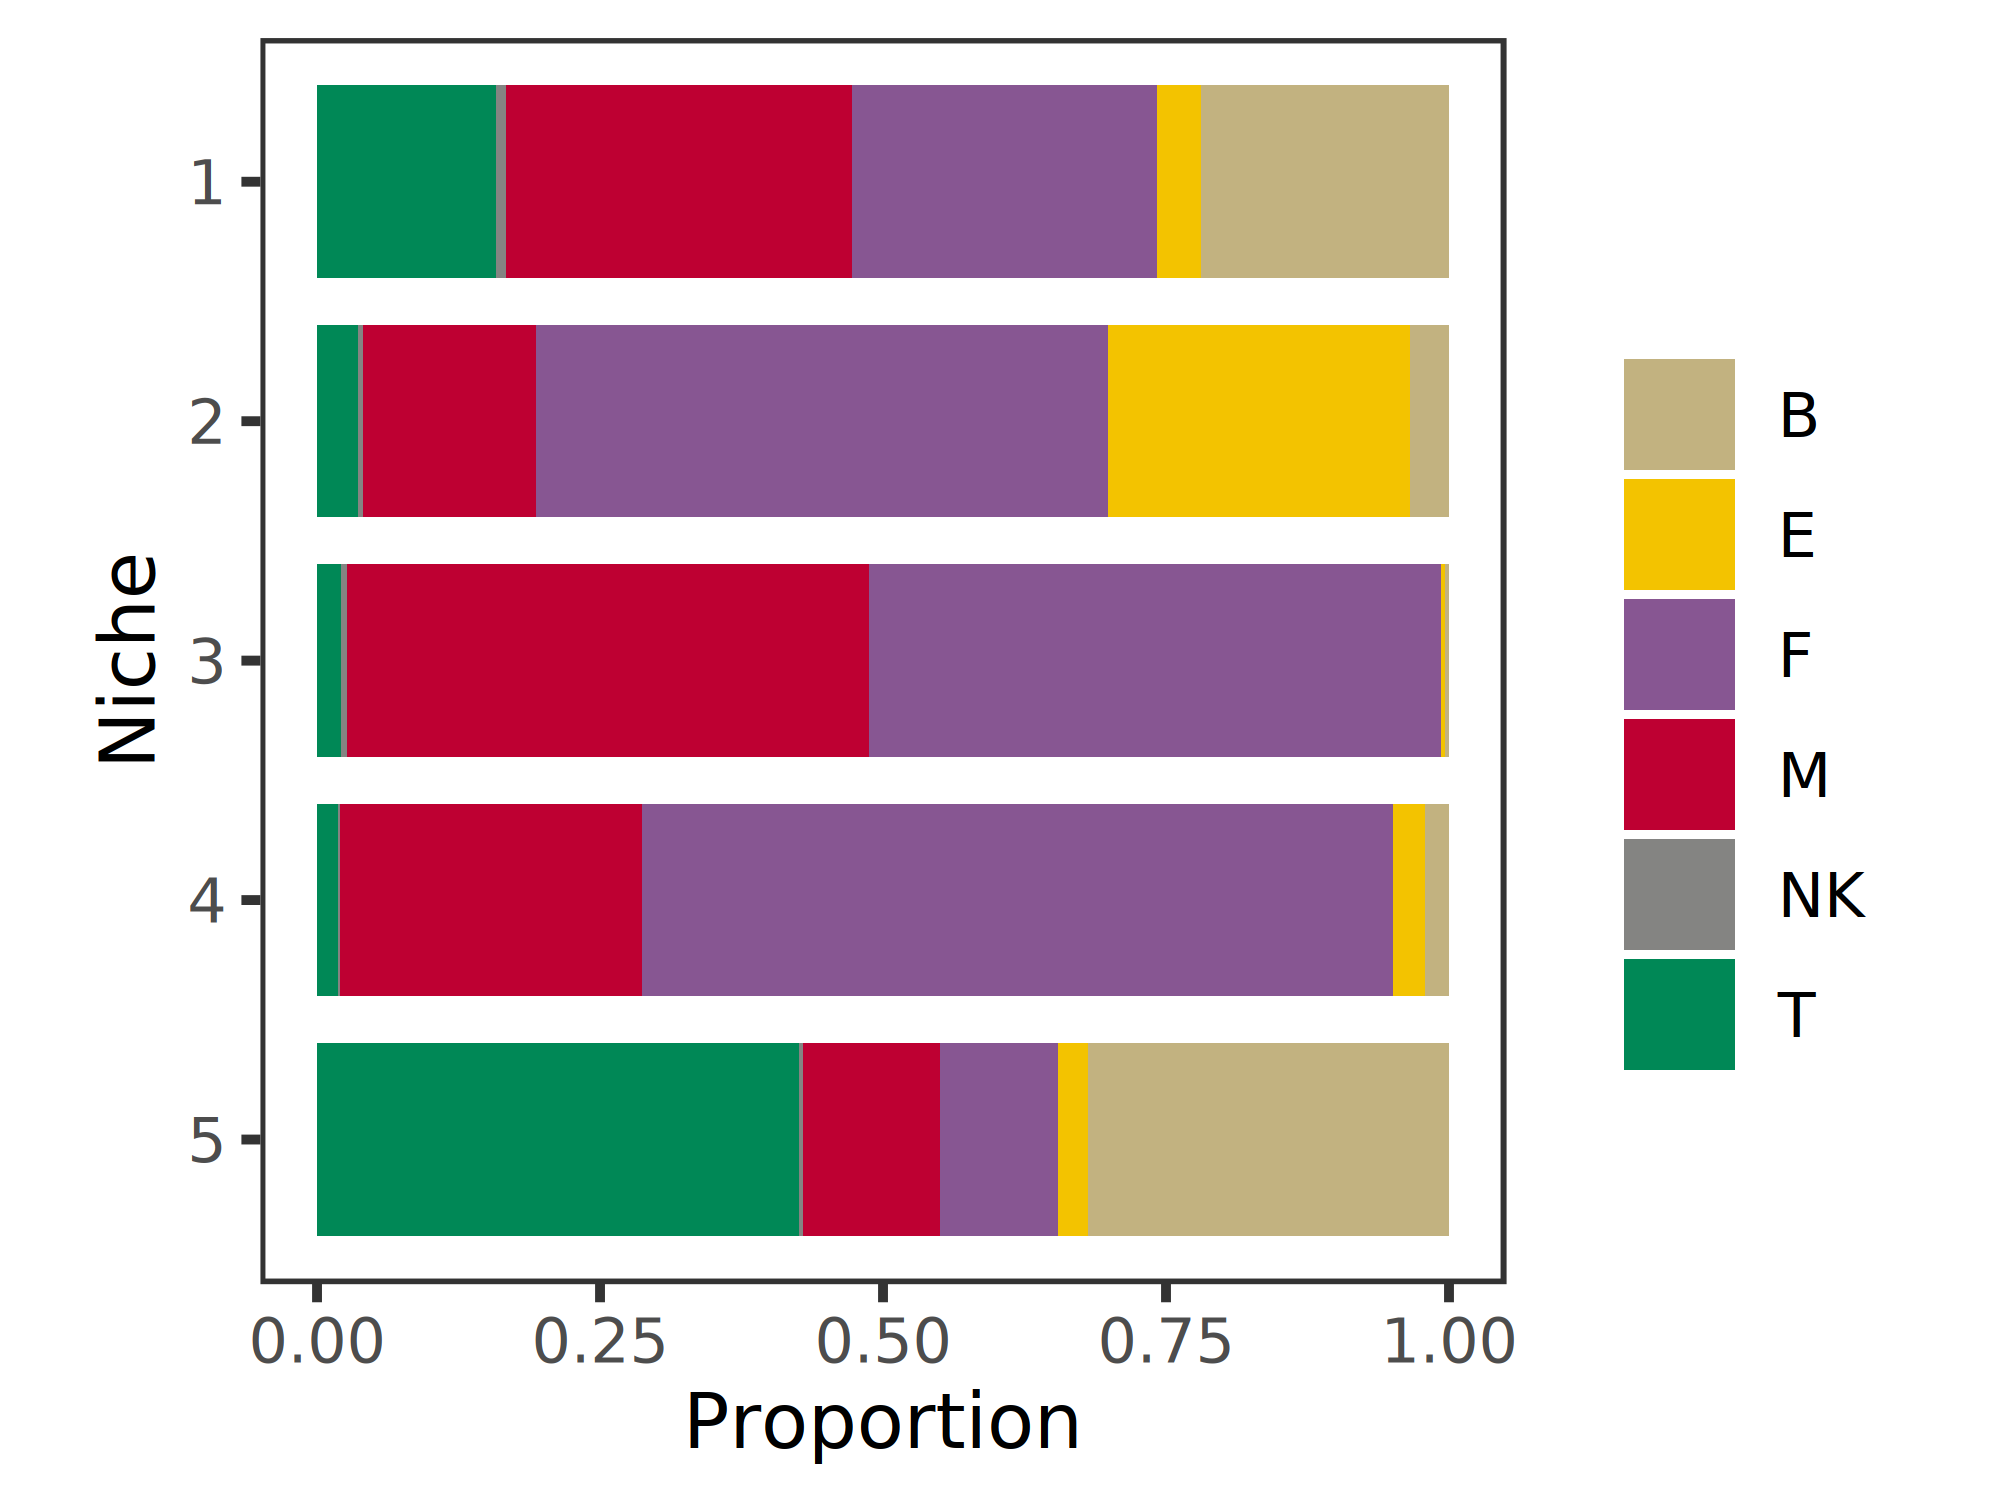

In [31]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 500)
ggplot(niche_major_ct_prop, aes(cell_prop, Niche, fill=ct_major_plt)) +
    geom_bar(stat="identity", width=0.8) +
    scale_fill_manual(values=major_ct_palettes) +
    theme_bw() +  
    theme(aspect.ratio=1,
          panel.grid=element_blank()) +
    labs(x="Proportion", fill="")
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1C/plot.png",
       height=3,
       width=4,
       dpi=500)

# Figure 1D

In [33]:
do.call(rbind, niche_metadata_all) %>%
    group_by(Niche, celltype_subcluster) %>%
    summarize(cell_count=n(), .groups="drop_last") %>%
    mutate(cell_prop=100*cell_count/sum(cell_count)) -> niche_sub_ct_prop

In [36]:
niche_sub_ct_prop %>%
    mutate(celltype_major=gsub("[0-9]+", "", as.character(celltype_subcluster)),
           Niche=factor(Niche, levels=rev(seq_len(5))),
           celltype_major=factor(celltype_major, levels=c("M", "F", "E", "B", "T", "NK"))) -> niche_sub_ct_prop

Warning message:
“Removed 76 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 76 rows containing missing values or values outside the scale range
(`geom_point()`).”


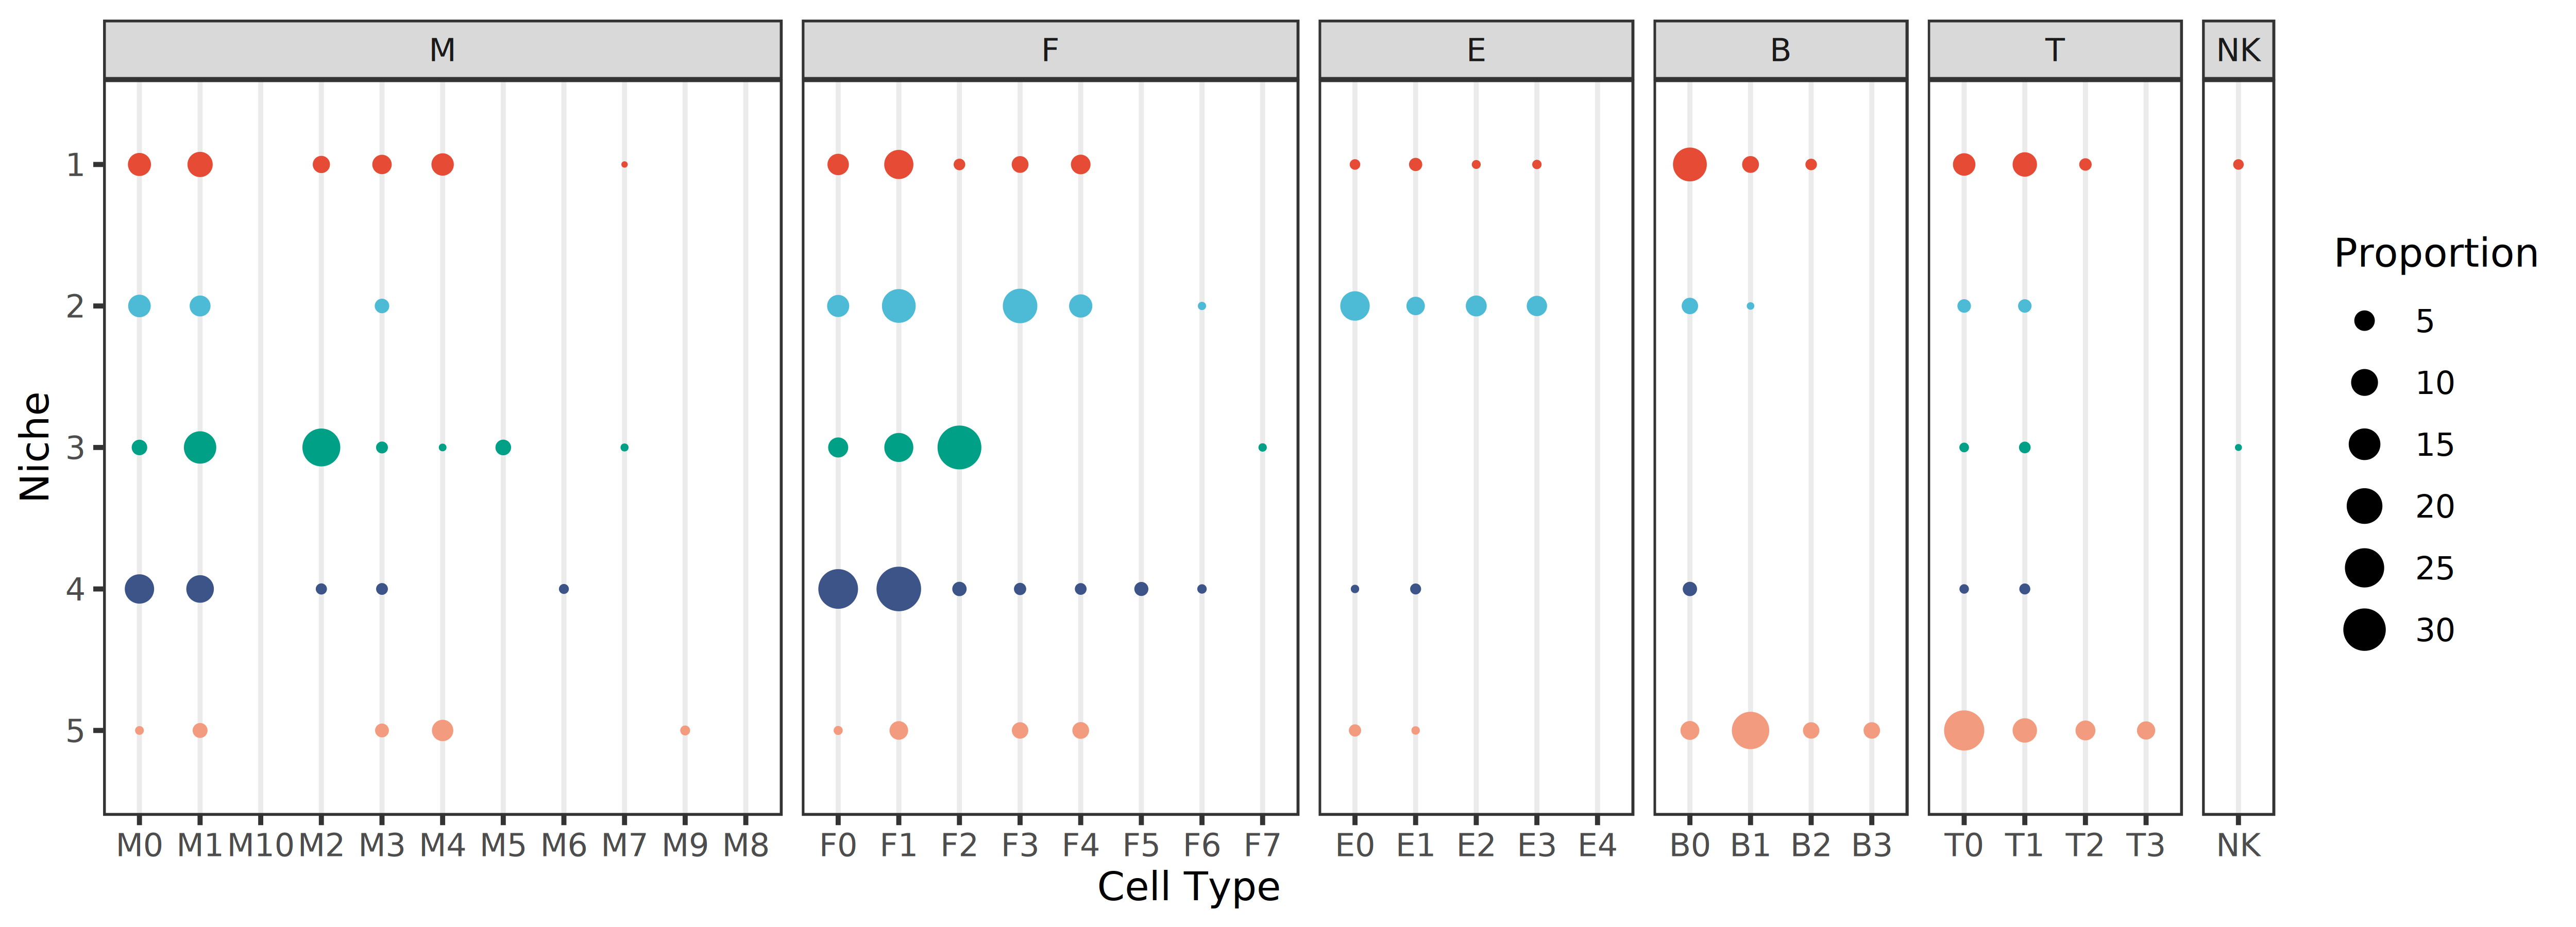

In [38]:
options(repr.plot.width = 10, repr.plot.height = 3.6, repr.plot.res = 500)
ggplot(niche_sub_ct_prop, aes(celltype_subcluster,
                              Niche,
                              size=ifelse(cell_prop >= 0.5, cell_prop, NA),
                              color=Niche)) +
    scale_size_continuous(range=c(0, 5), breaks=seq(5, 100, 5)) +
    geom_point() +
    theme_bw() +
    theme(panel.grid.major.y=element_blank()) +
    facet_grid(.~celltype_major, scales="free", space="free") +
    labs(x="Cell Type", y="Niche", size="Proportion", color="") +
    scale_color_manual(values=niche_palette, guide="none")
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1D/plot.png",
       height=3.6,
       width=10,
       dpi=500)

# Figure 1R

In [39]:
do.call(rbind, niche_metadata_all) %>%
    filter(ct_major_plt=="F") %>%
    group_by(Niche, sample, celltype_subcluster, .drop=FALSE) %>%
    summarize(cell_count=n(), .groups="drop_last") %>%
    mutate(cell_prop=100*cell_count/sum(cell_count)) %>%
    filter(celltype_subcluster=="F7") -> F7_prop_per_niche_per_sample

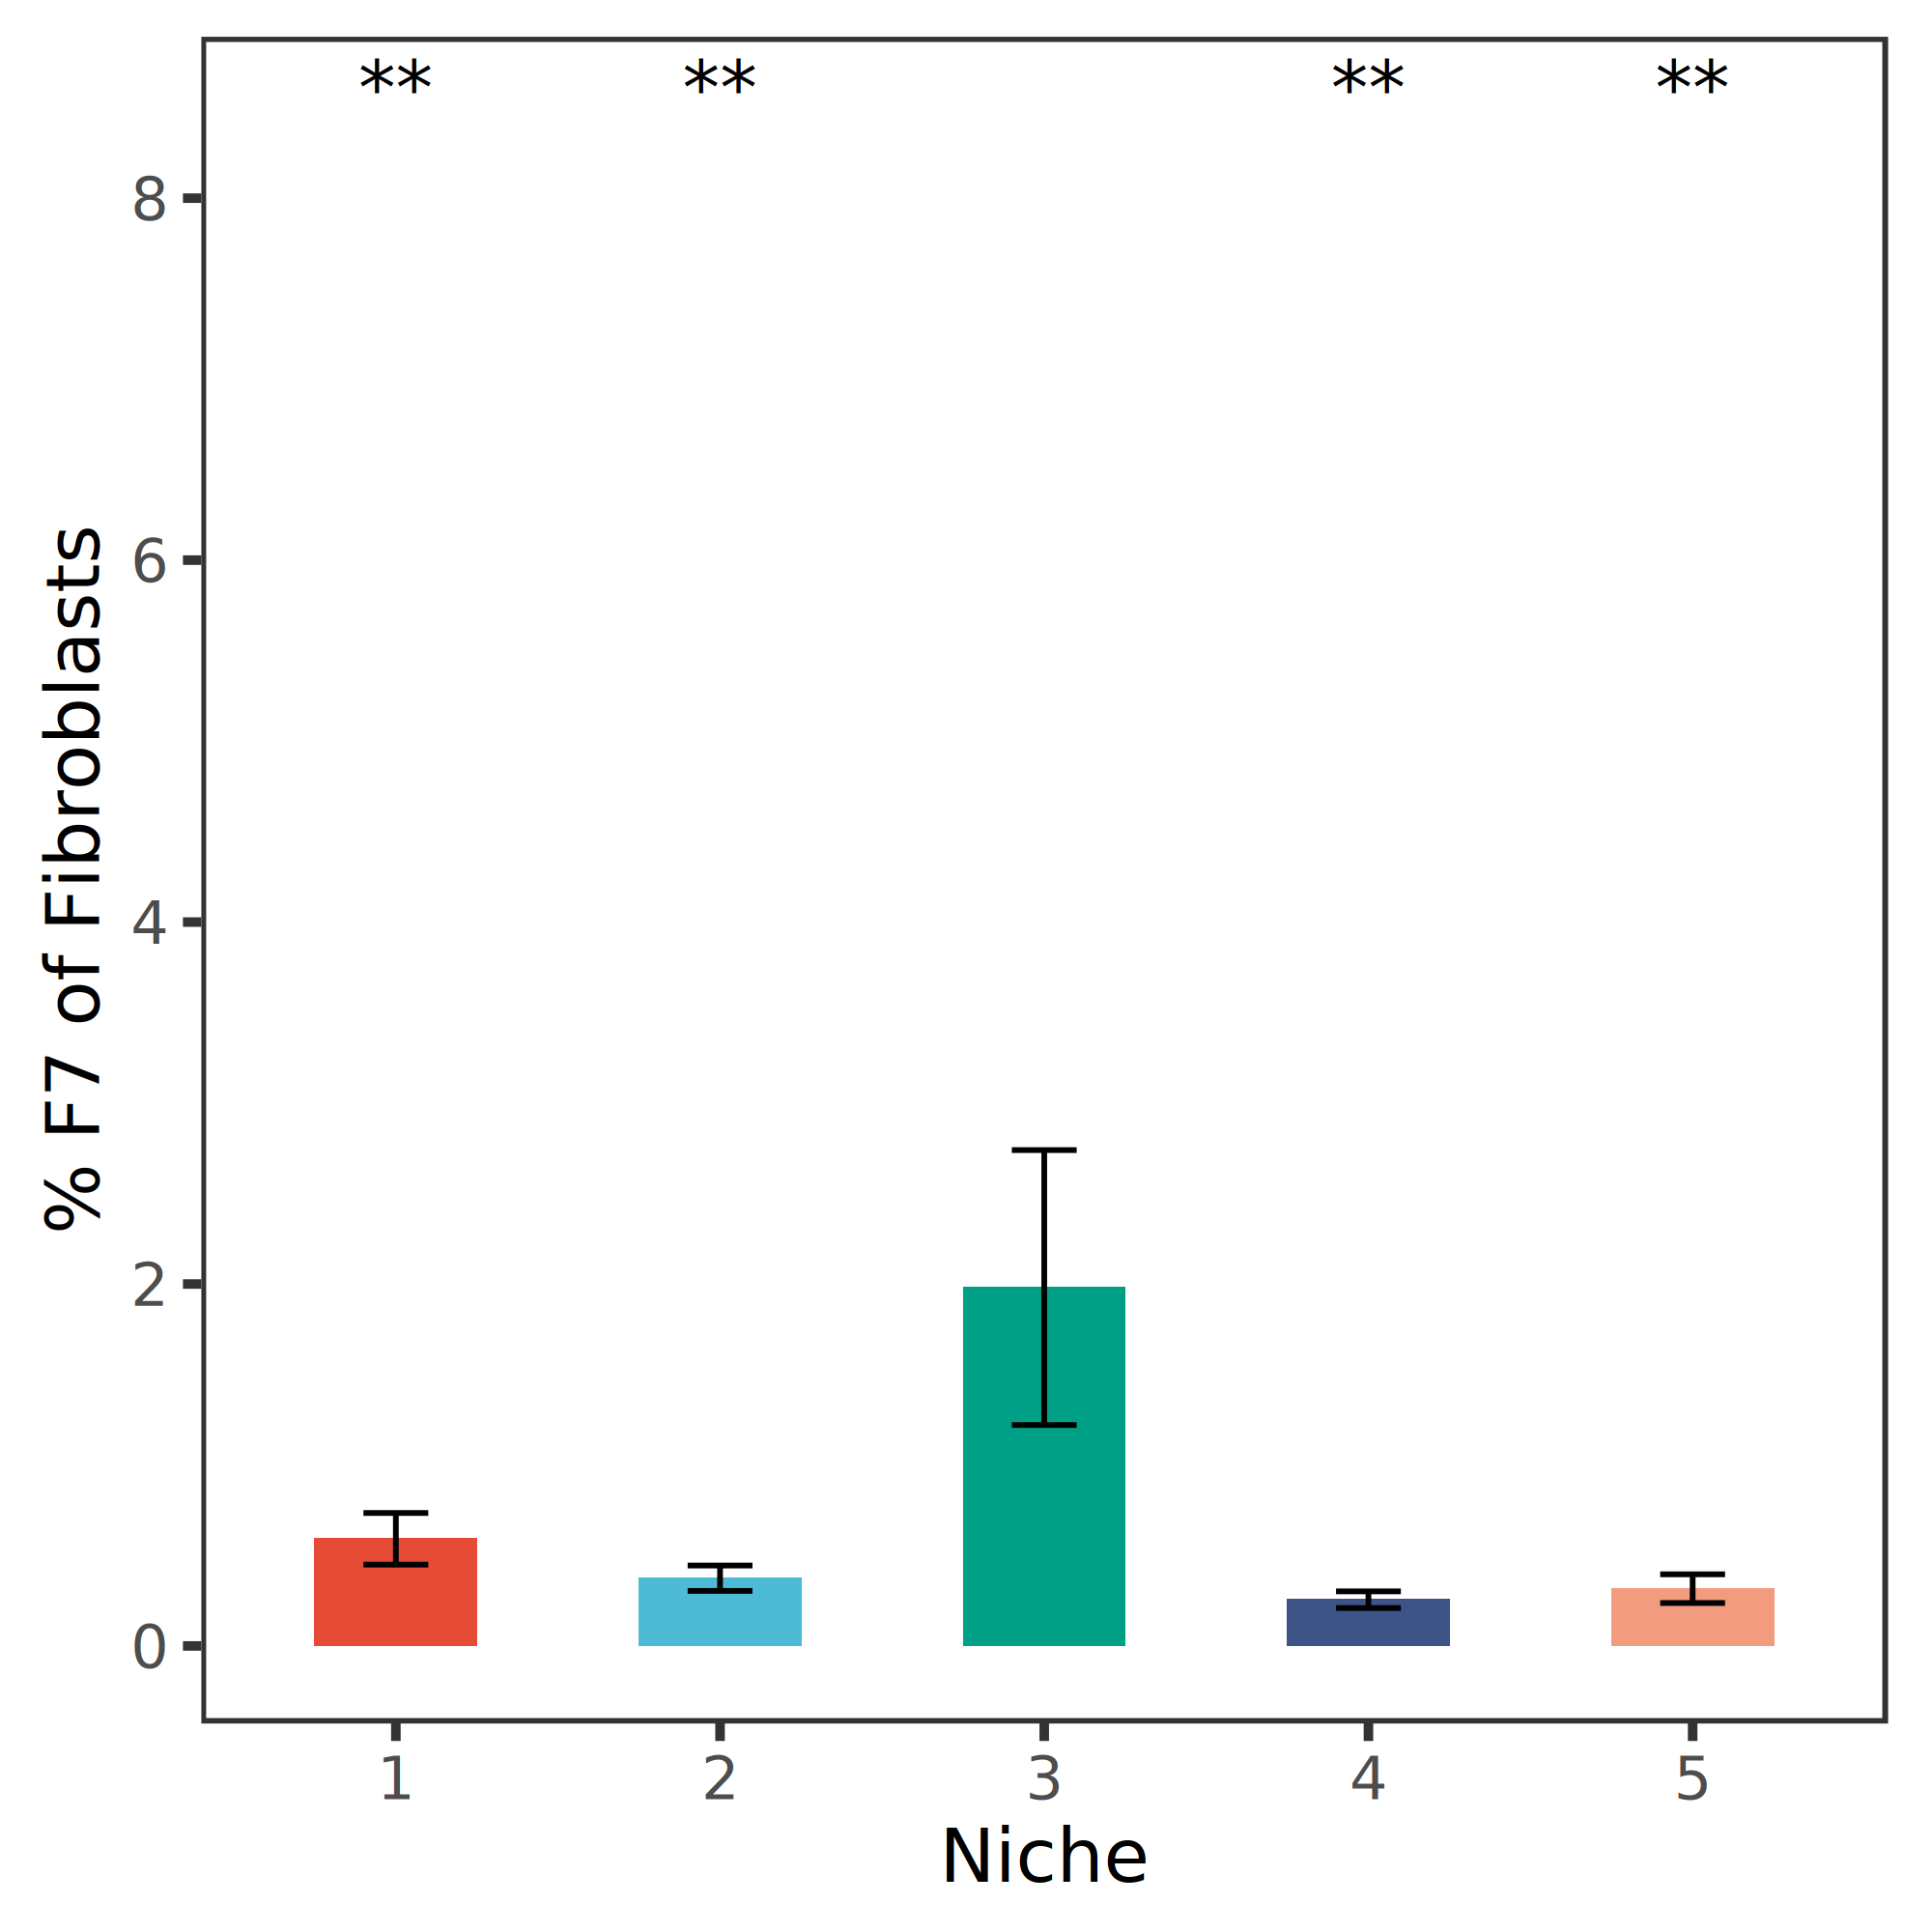

In [46]:
ggplot(F7_prop_per_niche_per_sample, aes(x = Niche, y = cell_prop)) +
  stat_summary(aes(fill=Niche), fun = mean, geom = "col", width = 0.5, linewidth = 0.3) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2, linewidth = 0.3) +
  scale_fill_manual(values = niche_palette) +
  stat_compare_means(
    ref.group = "3",
    paired = TRUE,
    label = "p.signif",
    method = "wilcox.test",
    method.args = list(alternative = "less"),
  ) +
  theme_bw() +
  scale_color_manual(values = paletteer::paletteer_d("ggsci::default_igv")) +
  theme(
    aspect.ratio = 1,
    panel.grid = element_blank(),
    legend.position = "none"
  ) +
  labs(x = "Niche", y = "% F7 of Fibroblasts")
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1E/plot.png",
       height=4,
       width=4,
       dpi=500)

# Figure 1F

In [47]:
resolution <- 50
all_CLQ_res <- mclapply(all_sample_ids, function(sample){
    clq_res <- qread(glue("/data1/deyk/harry/RA_Xenium/results/CLQ_res/Baysor/{sample}_CLQ_final_{resolution}.qs"))
    clq_res <- clq_res[!sapply(clq_res, is.null)]
    clq_vals <- sapply(clq_res, function(res){
        res$CLQ_global
    })
    clq_pvals <- sapply(clq_res, function(res){
        min(res$pval_global_CLQ, res$pval_global_CLQ_separation)
    })
    res_df <- data.frame(CLQ=clq_vals,
                         p=clq_pvals,
                         ct1=sapply(names(clq_vals), function(name){str_split_1(name, ",")[1]}),
                         ct2=sapply(names(clq_vals), function(name){str_split_1(name, ",")[2]}),
                         name=names(clq_vals),
                         sample=sample)
    return(res_df)
}, mc.cores=10)

In [53]:
discrete_pal <- paletteer_d("ggsci::signature_substitutions_cosmic")[c(3, 1, 4)]
names(discrete_pal) <- c("Positive colocalization", "Negative colocalization", "Not significant")

## This is a binarized version where we only call positive, negative, or non-significant CLQ. For CLQ to be significant, it has to agree and significant across all samples

In [55]:
do.call(rbind, all_CLQ_res) %>%
    mutate(p.adj=p.adjust(p, method="BH")) %>%
    group_by(ct1, ct2) %>%
    summarise(
    CLQ_sign_all = case_when(
      all(CLQ > 1, na.rm = TRUE) ~  1L,
      all(CLQ < 1, na.rm = TRUE) ~ -1L,
      TRUE                       ~  0L
    ),
    p.adj = max(p.adj, na.rm = TRUE),
    .groups = "drop"
    ) -> CLQ_binarized
labels_df <- CLQ_binarized %>%
  mutate(label = case_when(
    CLQ_sign_all ==  1 & p.adj <= 0.05 ~ "Positive colocalization",
    CLQ_sign_all == -1 & p.adj <= 0.05 ~ "Negative colocalization",
    TRUE                              ~ "Not significant"
  )) %>%
  select(ct1, ct2, label) %>%
  distinct()

CLQ_binarized <- labels_df %>%
  pivot_wider(names_from = ct2, values_from = label) %>%
  tibble::column_to_rownames("ct1")

## Also make a mean CLQ matrix for giving some structure to the binarized version. We use the hclust result from this mean CLQ heatmap

In [56]:
do.call(rbind, all_CLQ_res) %>%
    group_by(ct1, ct2) %>%
    summarise(
    mean_val=mean(CLQ),
    .groups = "drop"
    ) -> CLQ_mean
CLQ_mean  <- xtabs(mean_val ~ ct1 + ct2, data = CLQ_mean)

## Heatmap row annotation

In [57]:
broad_ct_group <- sapply(rownames(CLQ_binarized), function(ct){gsub("[0-9]", "", ct)})
ha_row <- rowAnnotation("Cluster"=unname(broad_ct_group),
                       col=list("Cluster"=major_ct_palettes),
                       annotation_name=NULL,
                       show_annotation_name=FALSE,
                       annotation_legend_param=list(title_gp=gpar(fontsize=8),
                                                    labels_gp=gpar(fontsize=8),
                                                    grid_height=unit(4.5, "mm"),
                                                    grid_width=unit(4.5, "mm")),
                       simple_anno_size=unit(2.5, "mm"))

Warning message:
“`legend_height` you specified is too small, use the default minimal
height.”
Warning message:
“`legend_height` you specified is too small, use the default minimal
height.”
Warning message:
“`legend_height` you specified is too small, use the default minimal
height.”
Warning message:
“`legend_height` you specified is too small, use the default minimal
height.”
Warning message:
“`legend_height` you specified is too small, use the default minimal
height.”


agg_record_957428047 
                   2

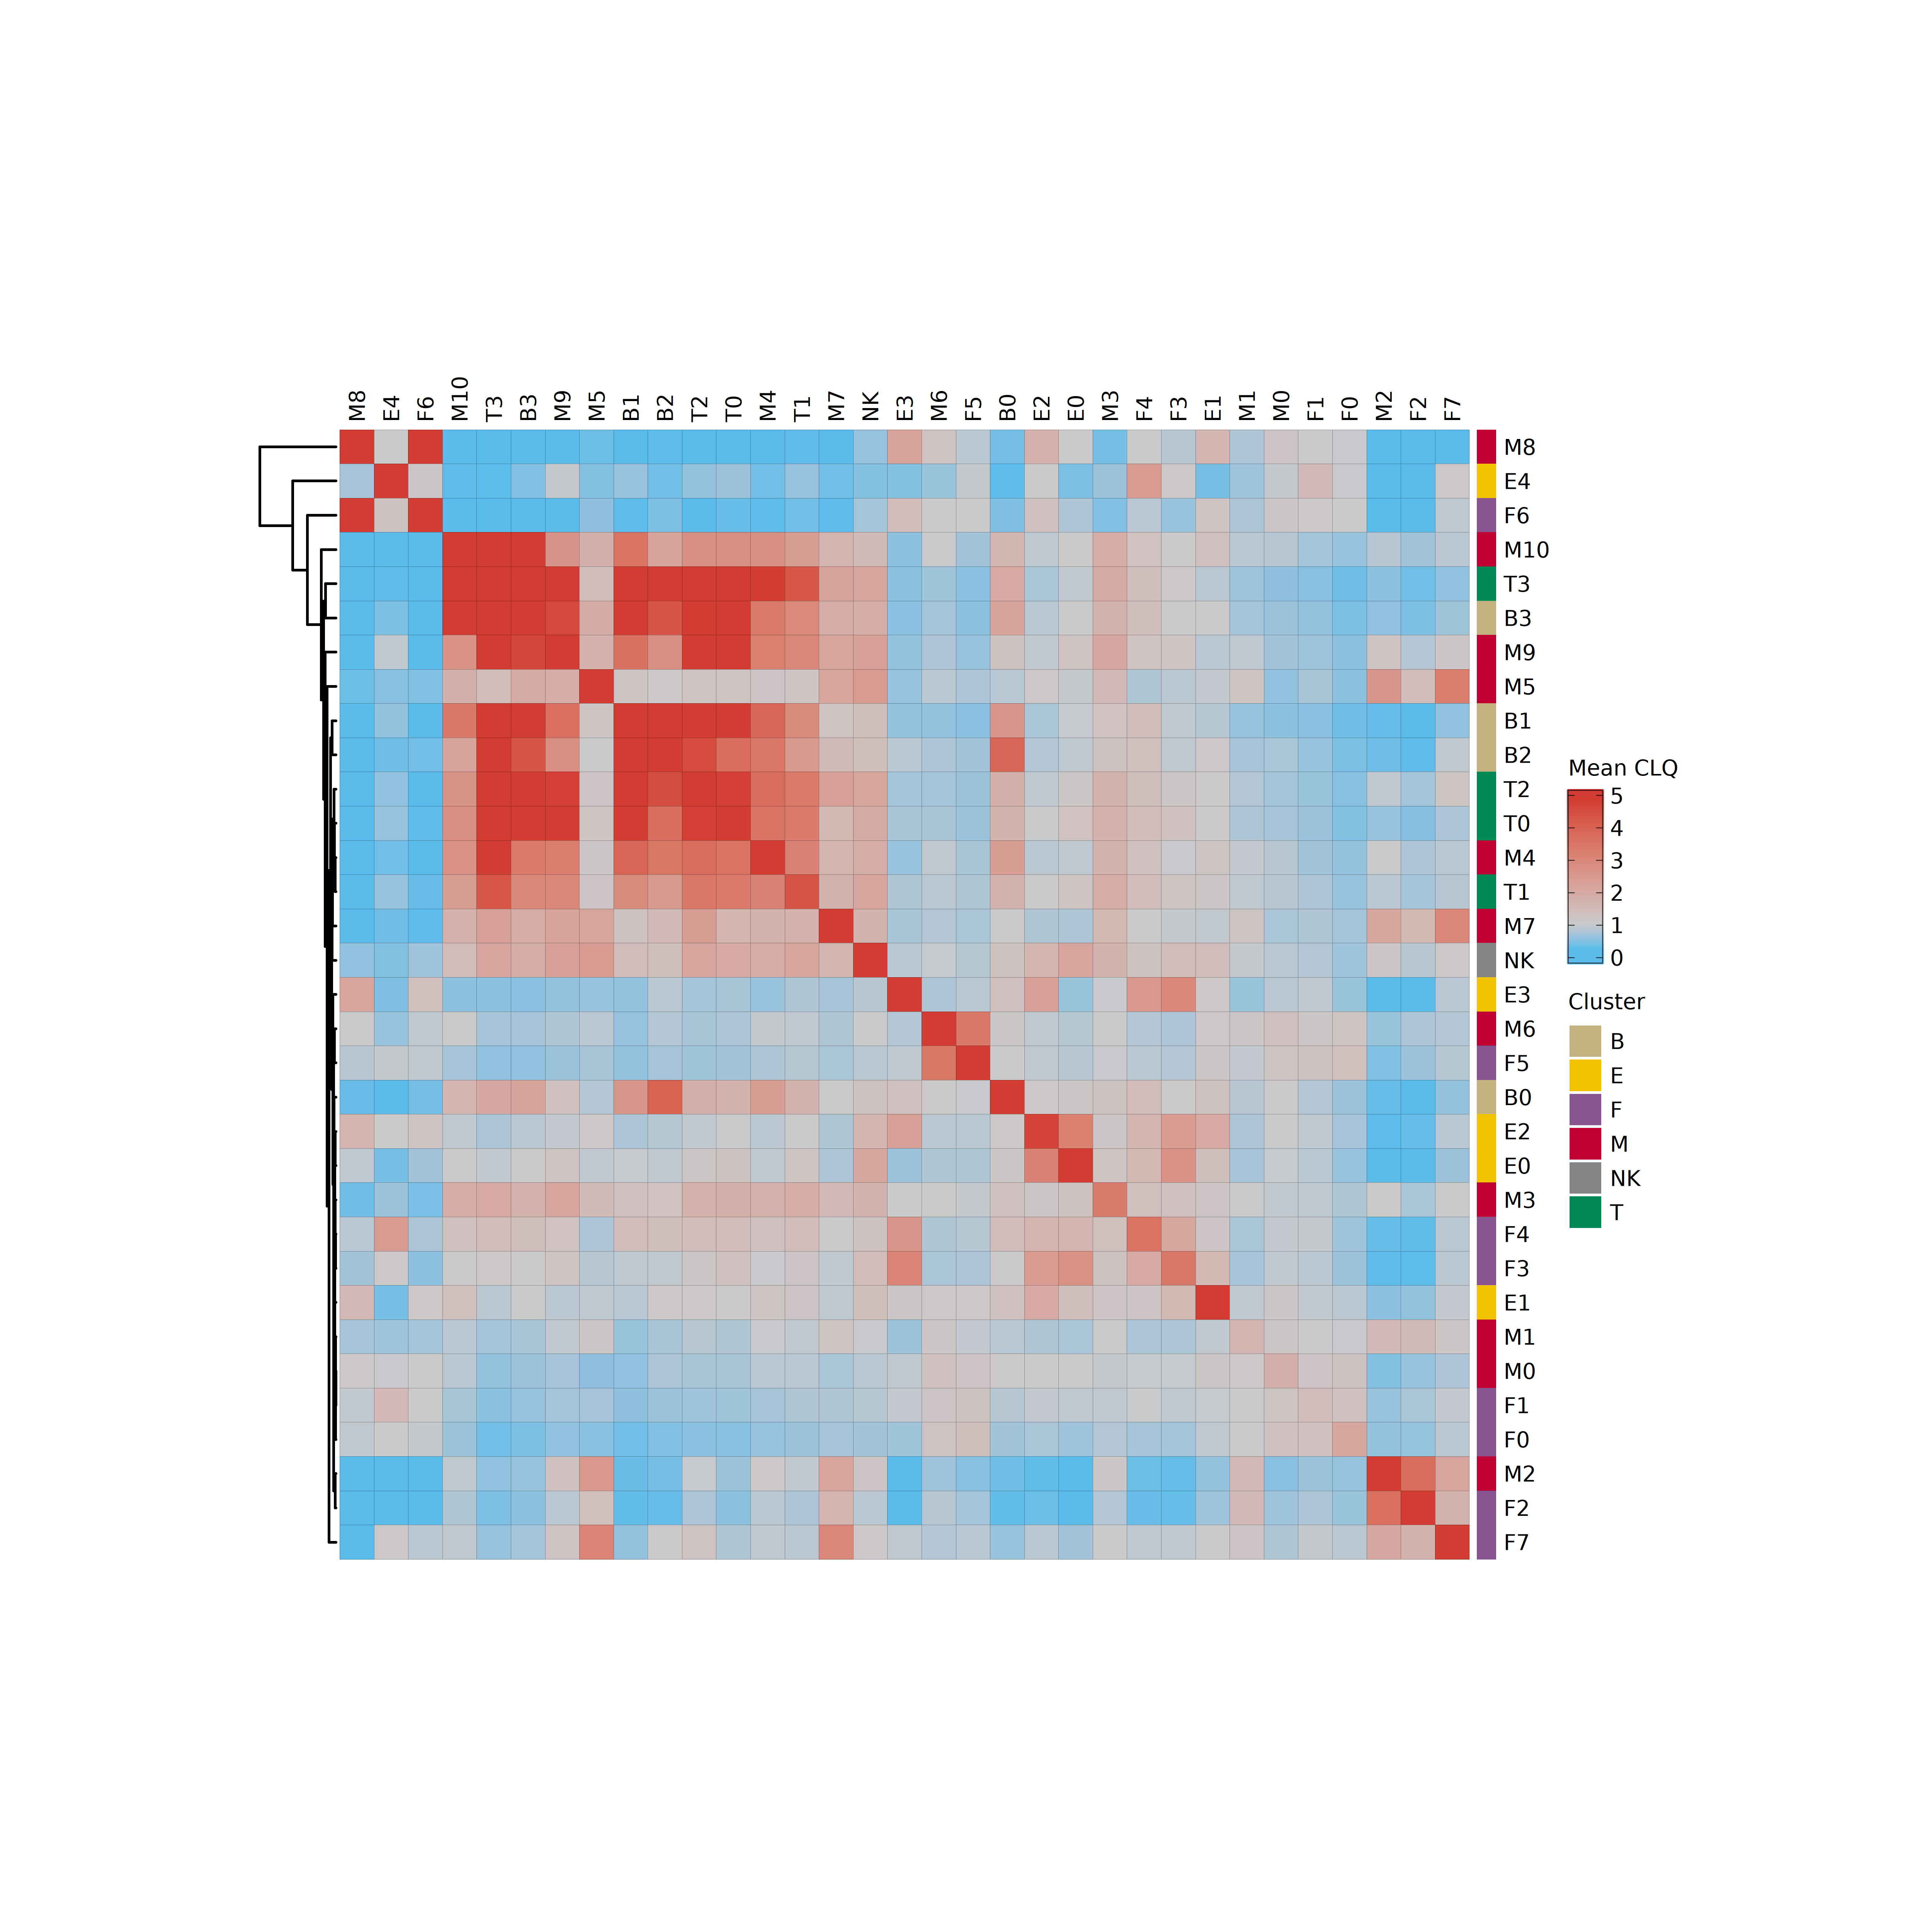

In [58]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 500)
Heatmap(CLQ_mean,
        col=circlize::colorRamp2(c(quantile(CLQ_mean, 0.05), 1, quantile(CLQ_mean, 0.95)),
                                 c(discrete_pal[2], discrete_pal[3], discrete_pal[1])),
        row_names_gp=gpar(fontsize = 8),
        column_names_gp=gpar(fontsize = 8),
        row_title=NULL,
        column_title=NULL,
        rect_gp=gpar(col = "black", lwd = 0.05),
        column_names_side="top",
        column_dend_side="bottom",
        name="Mean CLQ",
        right_annotation=ha_row,
        show_column_dend=FALSE,
        width=unit(ncol(CLQ_binarized) * 4.5, "mm"),
        height=unit(nrow(CLQ_binarized) * 4.5, "mm"),
        heatmap_legend_param=list(title_gp=gpar(fontsize=8),
                              labels_gp=gpar(fontsize=8),
                              legend_height=unit(2, "cm"),
                              grid_width=unit(4.5, "mm"),
                              legend_gp=gpar(lwd=0.25),
                              border = TRUE)) -> mean_CLQ_heatmap
mean_CLQ_heatmap <- draw(mean_CLQ_heatmap)
pdf(file=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1F/mean_CLQ_resolution_{resolution}.pdf"),
    width=10,
    height=10)
mean_CLQ_heatmap
dev.off()

In [59]:
diag(CLQ_binarized) <- NA

Warning message:
“The input is a data frame-like object, convert it to a matrix.”
Warning message:
“Note: not all columns in the data frame are numeric. The data frame
will be converted into a character matrix.”


agg_record_627224642 
                   2

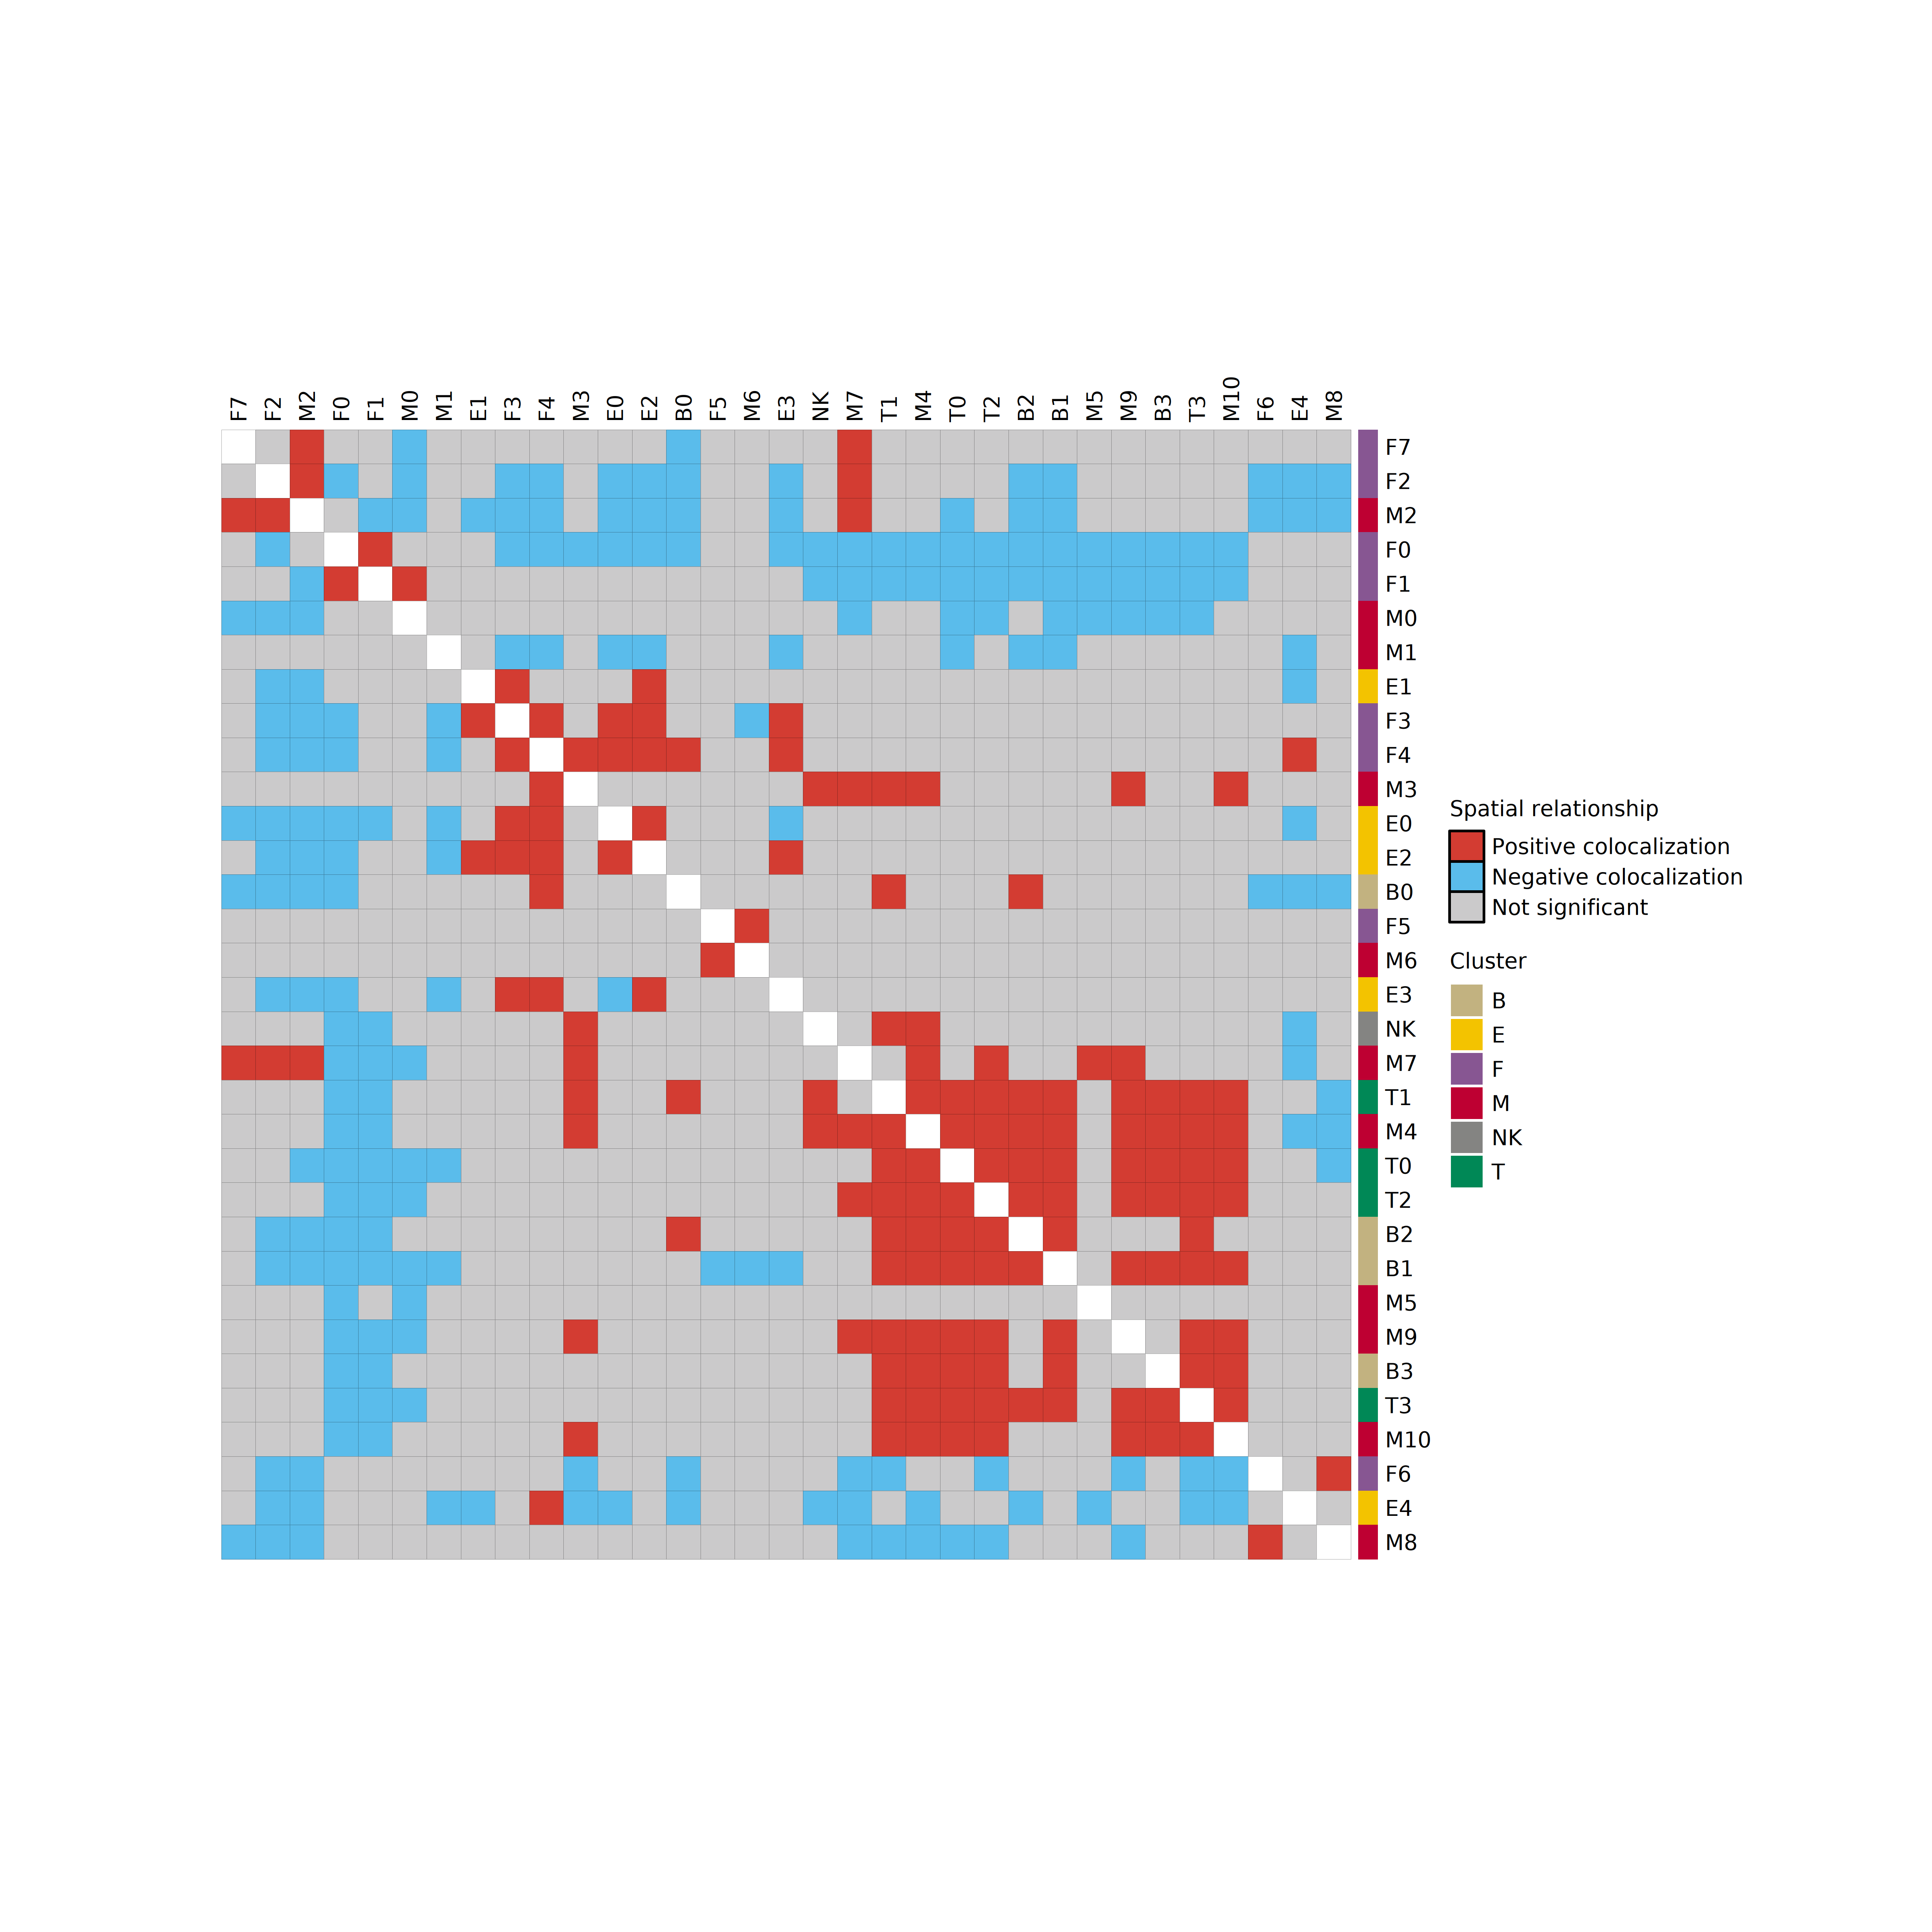

In [70]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 500)
Heatmap(CLQ_binarized,
        col=discrete_pal,
        na_col="white",
        row_names_gp=gpar(fontsize = 8),
        column_names_gp=gpar(fontsize = 8),
        row_title=NULL,
        column_title=NULL,
        row_order=rownames(CLQ_mean)[rev(row_order(mean_CLQ_heatmap))],
        column_order=colnames(CLQ_mean)[rev(column_order(mean_CLQ_heatmap))],
        rect_gp=gpar(col = "black", lwd = 0.05),
        column_names_side="top",
        column_dend_side="bottom",
        name="Spatial relationship",
        right_annotation=ha_row,
        show_column_dend=FALSE,
        width=unit(ncol(CLQ_binarized) * 4.5, "mm"),
        height=unit(nrow(CLQ_binarized) * 4.5, "mm"),
        heatmap_legend_param=list(title_gp=gpar(fontsize=8),
                              labels_gp=gpar(fontsize=8),
                              legend_height=unit(2, "cm"),
                              grid_width=unit(4.5, "mm"),
                              legend_gp=gpar(lwd=0.25),
                              border = TRUE)) -> discrete_CLQ_heatmap
discrete_CLQ_heatmap <- draw(discrete_CLQ_heatmap)
pdf(file=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1F/discrete_CLQ_resolution_{resolution}.pdf"),
    width=10,
    height=10)
discrete_CLQ_heatmap
dev.off()

# Figure 1G

In [71]:
neighbor_count_all <- lapply(all_sample_ids, function(sample){
    nn_mat <- qread(glue("/data1/deyk/harry/RA_Xenium/data/neighbors/neighbor_matrices/Baysor/{sample}_neighbors_radius_50_final.qs"))
    obj <- qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
    m25_cells <- which(Idents(obj) %in% c("M2", "M5"))
    all_m25_neighbors <- unique(unlist(apply(nn_mat[m25_cells, ], 1, function(neighbors){
        nn.tmp <- neighbors[-1]
        nn.tmp[nn.tmp!=0]
    })))
    neighbor_ct_count <- table(Idents(obj)[all_m25_neighbors])
    neighbor_ct_count <- data.frame(near_m25_count=as.numeric(neighbor_ct_count),
                                    ct=names(neighbor_ct_count))
    dataset_count <- table(Idents(obj))
    dataset_count <- data.frame(dataset_count=as.numeric(dataset_count),
                                ct=names(dataset_count))
    dataset_count %>%
    left_join(neighbor_ct_count, by="ct") %>%
    replace(is.na(.), 0) %>%
    mutate(sample_id=sample)
})

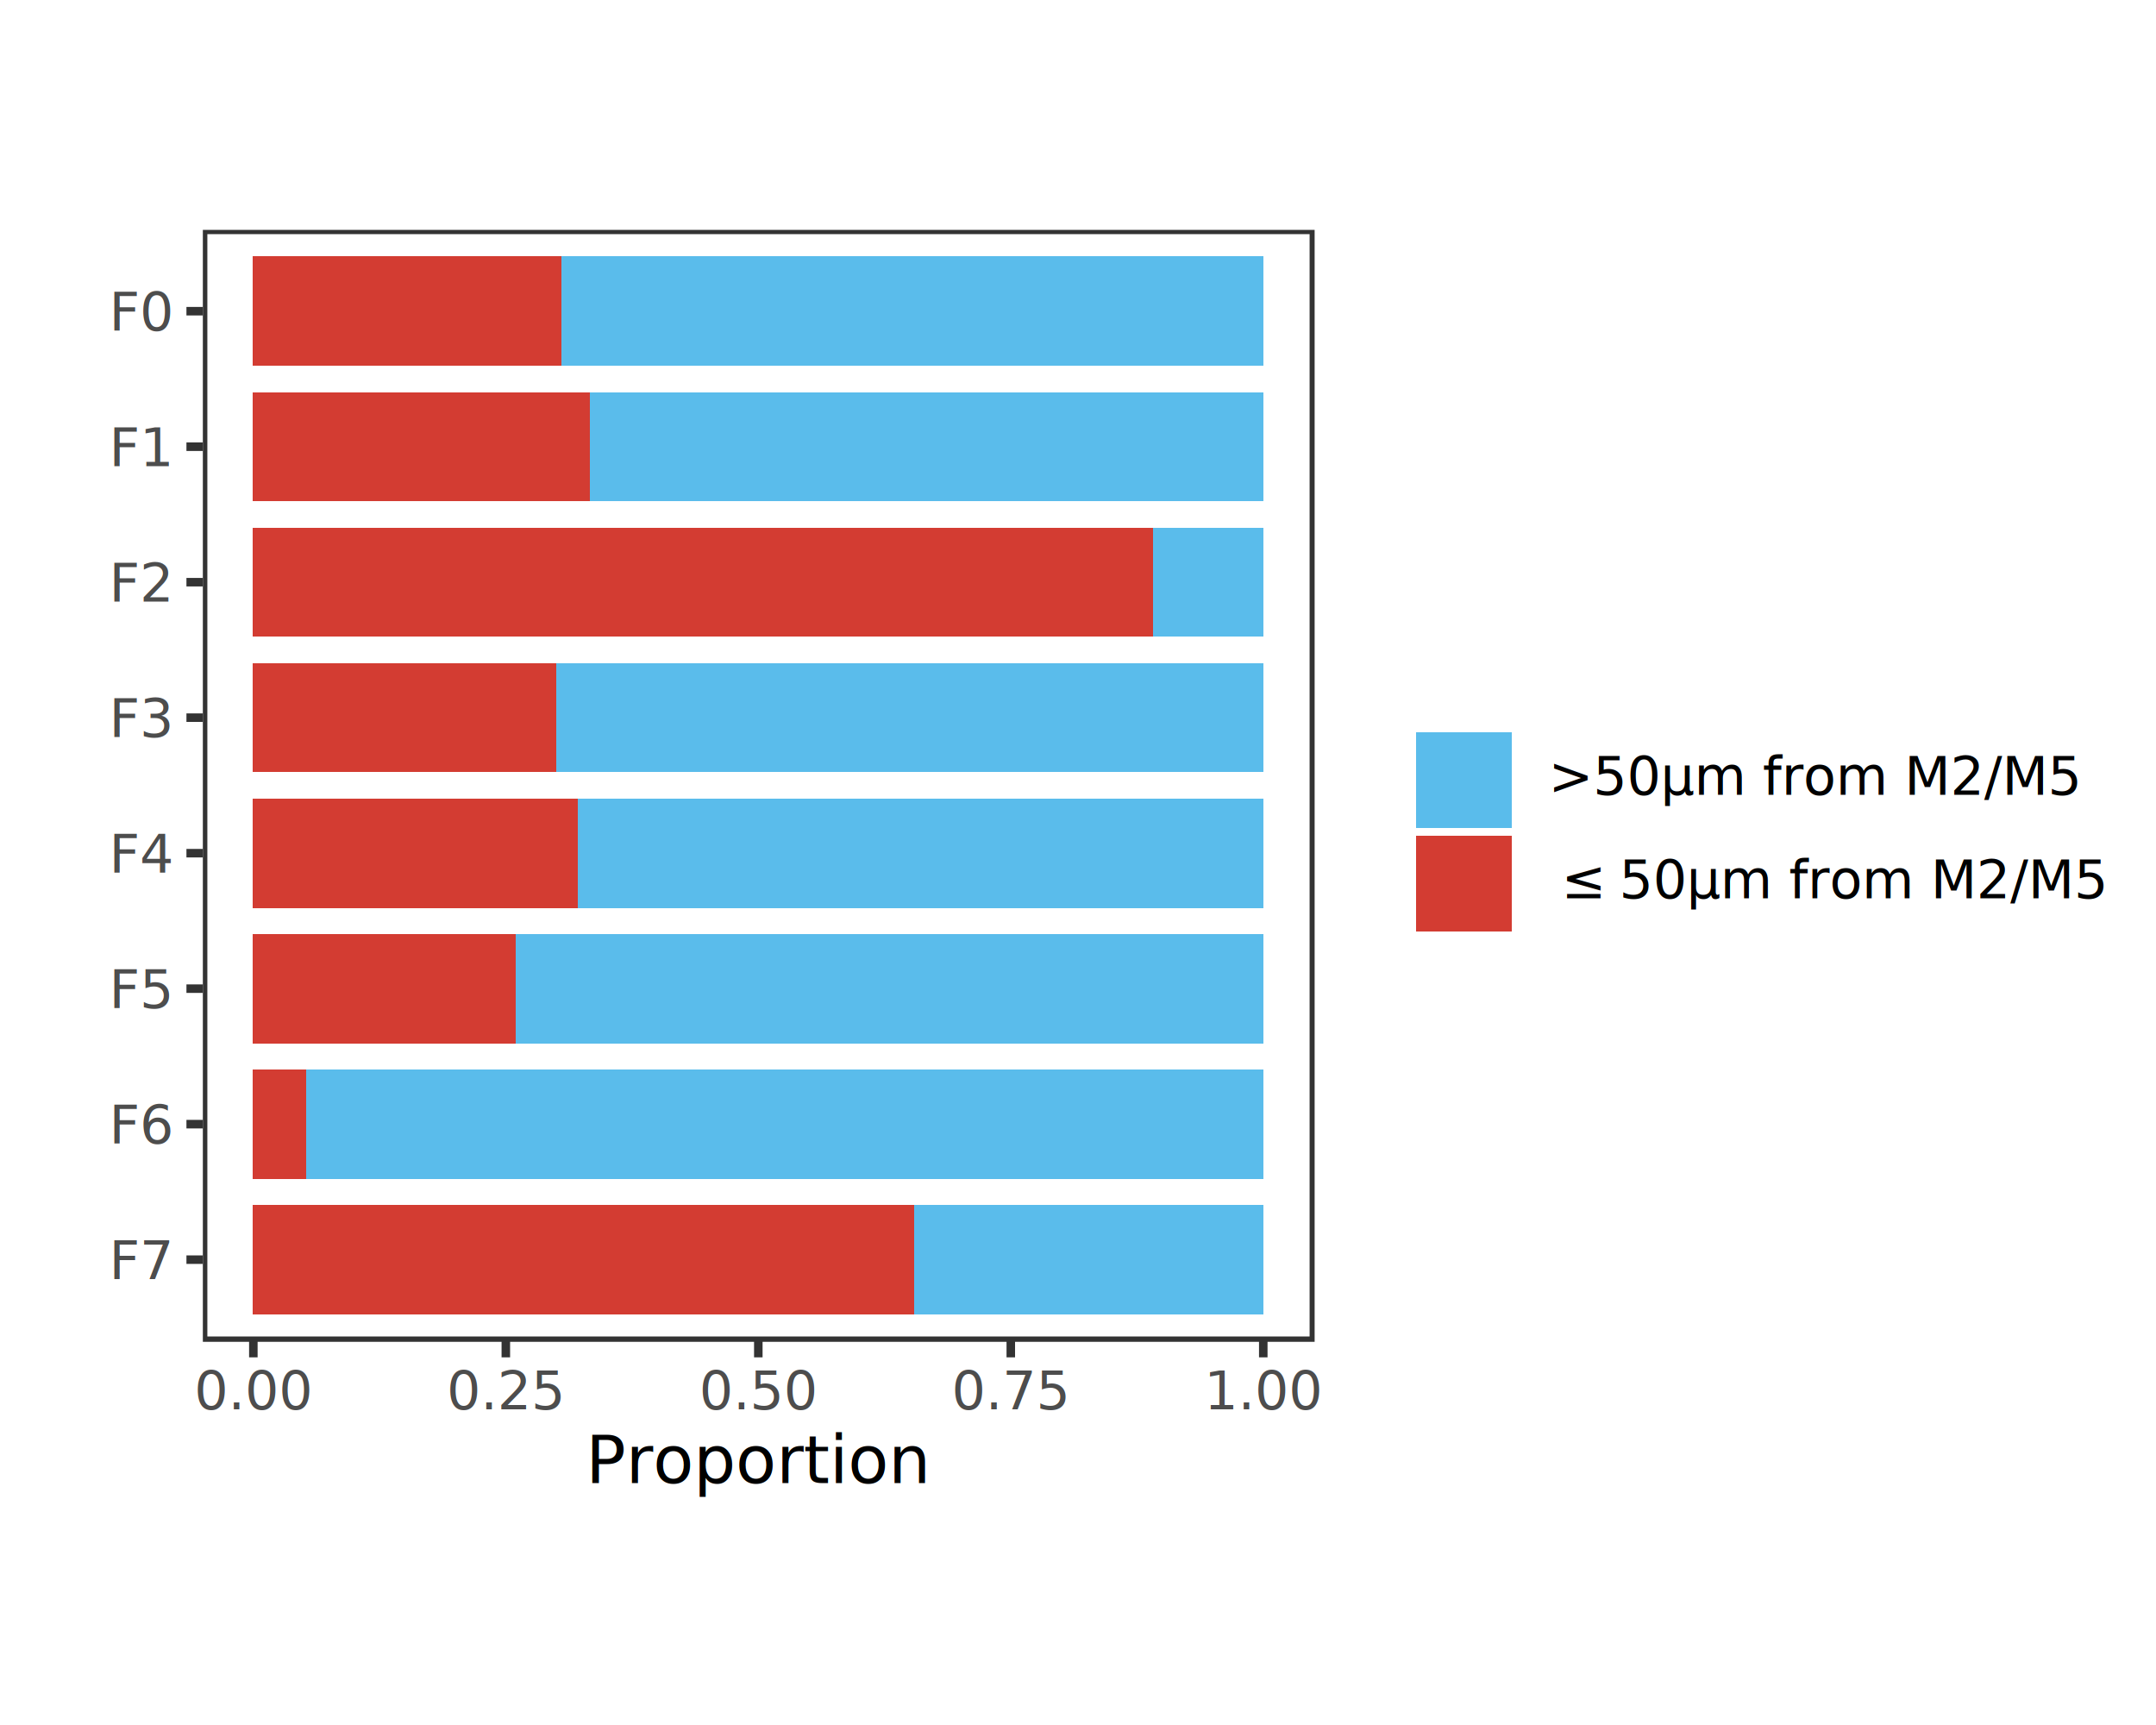

In [75]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 500)
do.call(rbind, neighbor_count_all) %>%
    filter(grepl("F", ct)) %>%
    mutate(ct=factor(ct, levels=rev(sort(unique(ct))))) %>%
    group_by(ct) %>%
    summarize(total_count=sum(dataset_count),
              near_count=sum(near_m25_count)) %>%
    mutate(prop_near=near_count/total_count,
           prop_not_near=1-prop_near) %>%
    pivot_longer(cols=c(prop_near, prop_not_near),
                 values_to="proportion",
                 names_to="type") %>%
    mutate(type=factor(type, levels=c("prop_not_near", "prop_near"))) %>%
    ggplot(., aes(proportion, ct, fill=type)) +
    geom_bar(stat="identity", width=0.8) +
    theme_bw() +  
    theme(aspect.ratio=1,
          panel.grid=element_blank()) +
    labs(x="Proportion", y="", fill="") +
    scale_fill_manual(values=paletteer_d("ggsci::signature_substitutions_cosmic")[c(1, 3)],
                      labels=c(TeX(r"(>50$\mu m$ from M2/M5)"), TeX(r"($\leq 50\mu m$ from M2/M5)")))
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1G/plot.png",
       height=4,
       width=5,
       dpi=500)

# Figure 1H

In [76]:
all_xenium_samples <- lapply(all_sample_ids, function(sample){
    qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
})

In [77]:
all_xenium_samples <- lapply(all_xenium_samples, function(obj){
    # discard assays we don't need, merging will be faster this way
    DefaultAssay(obj) <- "Xenium"
    obj[["SCT"]] <- NULL
    obj[["ControlCodeword"]] <- NULL
    obj[["ControlProbe"]] <- NULL
    obj@images <- list()
    return(obj)
})

In [78]:
all_xenium_merged <- merge(all_xenium_samples[[1]], all_xenium_samples[-1])
all_xenium_merged[["Xenium"]] <- JoinLayers(all_xenium_merged[["Xenium"]])

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


In [79]:
all_xenium_merged <- NormalizeData(all_xenium_merged, normalization.method="LogNormalize")

Normalizing layer: counts



In [80]:
all_xenium_merged_fibroblast <- subset(all_xenium_merged, subset=celltype_broad=="fibroblast-cells")

In [81]:
fig_1h_gene_list <- c(
    "HBEGF", "AMTN", "HTRA4", "GJB2", "DIRC3",
  "GPR1", "CLIC5", "MMP3", "MMP1", "DEFB1",
  "TOP2A", "CDK1", "MKI67", "UBE2C", "CCNB2",
  "CENPF", "APOBEC3A", "SPP1", "PCNA", "SERPINE1"
)

In [82]:
avg_expression_1h_genes <- AverageExpression(object=all_xenium_merged_fibroblast, group.by="celltype_subcluster", slot="data", features=fig_1h_gene_list)$Xenium
percent_expressing_1h_genes <- Percent_Expressing(seurat_object=all_xenium_merged_fibroblast, features=fig_1h_gene_list, group_by="celltype_subcluster")
percent_expressing_1h_genes %>%
    mutate(gene=rownames(.)) %>%
    pivot_longer(!gene, names_to="cell_type", values_to="pct_exp") -> percent_expressing_1h_genes
scaled_avg_exp_1h_genes <- t(scale(t(avg_expression_1h_genes)))
scaled_avg_exp_1h_genes <- MinMax(scaled_avg_exp_1h_genes, max=2.5, min=-2.5)

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


In [83]:
data.frame(scaled_avg_exp_1h_genes) %>%
    mutate(gene=rownames(.)) %>%
    pivot_longer(!gene, names_to="cell_type", values_to="z_avg_exp") -> scaled_avg_exp_1h_genes
percent_expressing_1h_genes %>%
    left_join(scaled_avg_exp_1h_genes, by=c("gene", "cell_type")) -> fig_1h_dotplot

In [84]:
fig_1h_dotplot$cell_type <- factor(fig_1h_dotplot$cell_type, levels=paste("F", seq_along(unique(fig_1h_dotplot$cell_type))-1, sep=""))
fig_1h_dotplot$gene <- factor(fig_1h_dotplot$gene, levels=unique(fig_1h_dotplot$gene))

In [85]:
options(repr.plot.width = 7.5, repr.plot.height = 3.2, repr.plot.res = 500)
color_scale_breaks_1h <- c(min(fig_1h_dotplot$z_avg_exp)+1e-1, max(fig_1h_dotplot$z_avg_exp)-1e-1)

## Function to customize mid point of color scales, from scico package

In [86]:
mid_rescaler <- function(mid) {
      function(x, to = c(0, 1), from = range(x, na.rm = TRUE)) {
        scales::rescale_mid(x, to, from, mid)
      }
    }
rescaler_1h <- mid_rescaler(0)

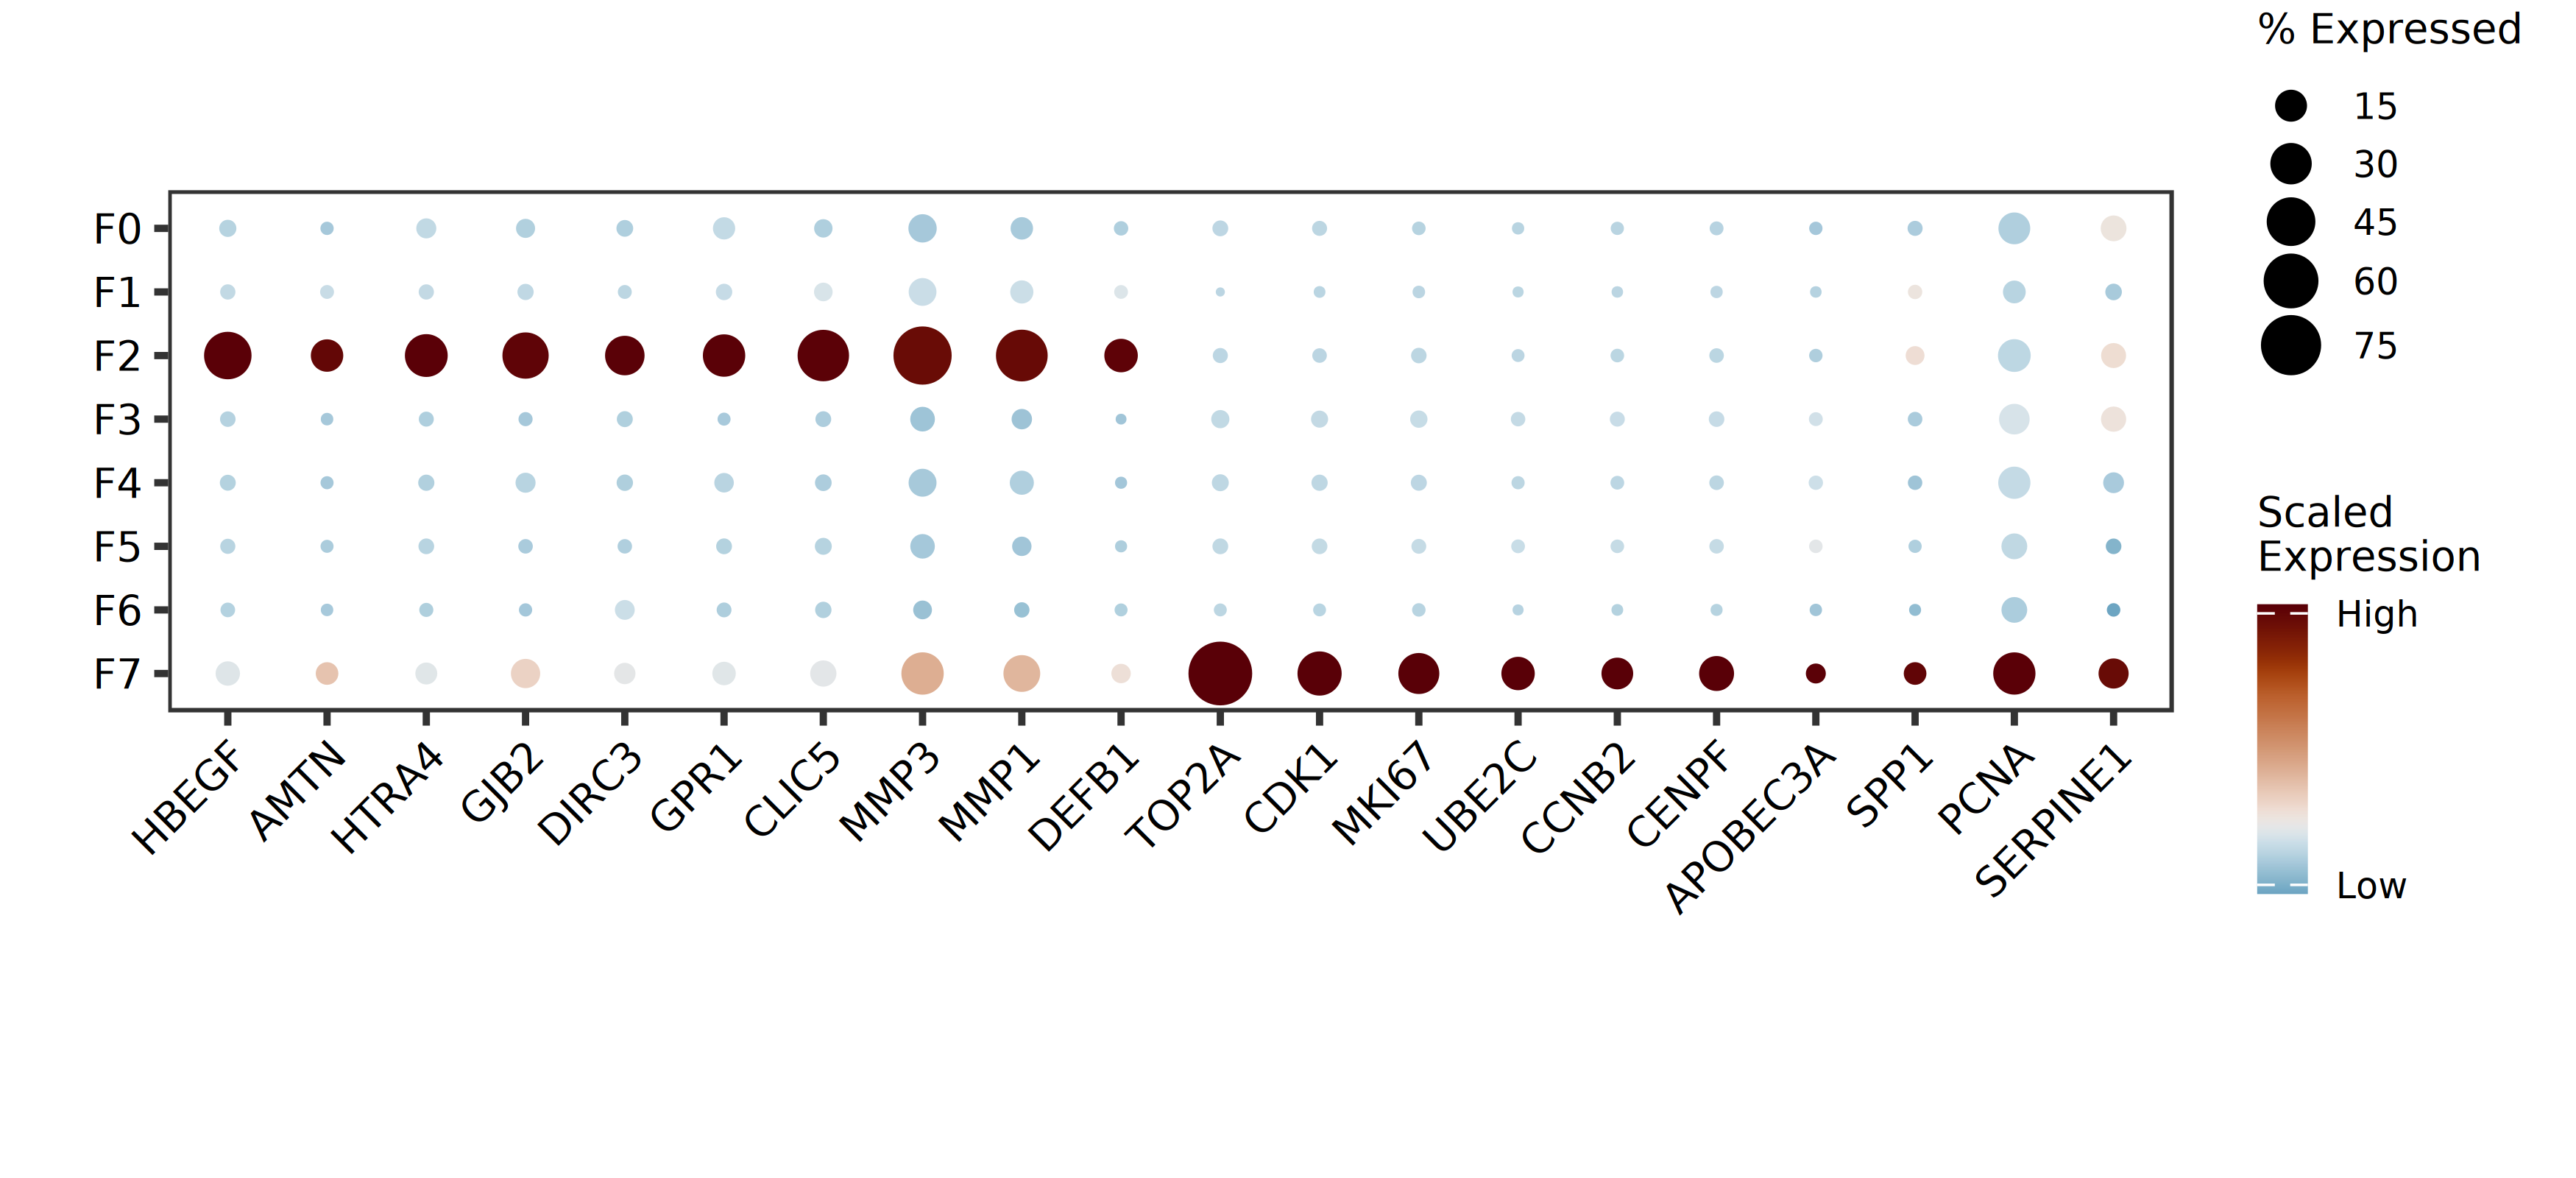

In [92]:
options(repr.plot.width = 7, repr.plot.height = 3.2, repr.plot.res = 500)
ggplot(fig_1h_dotplot %>% mutate(cell_type=factor(cell_type, levels=rev(unique(cell_type)))), aes(gene,
                           cell_type,
                           color=z_avg_exp,
                           size=pct_exp)) +
scale_size_continuous(range=c(0, 5), breaks=seq(15, 75, 15)) +
scale_color_gradientn(colors=paletteer_c("scico::vik", n=100),
                      rescale=rescaler_1h,
                      breaks=color_scale_breaks_1h,
                      labels=c("Low", "High")) +
geom_point() +
theme_bw() +
theme(axis.text.x=element_text(colour="black", angle=45, hjust=1, size=8),
      axis.text.y=element_text(colour="black", size=8),
      legend.key.height=unit(0.4, 'cm'),
      legend.key.width=unit(0.35, 'cm'),
      panel.grid.major=element_blank(),
      panel.grid.minor=element_blank(),
      legend.title=element_text(size=8),
      legend.text=element_text(size=7),
      aspect.ratio=0.26) +
ylab("") +
xlab("") +
labs(color="Scaled\nExpression",
     size="% Expressed")
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1H/plot.png",
       height=3.2,
       width=7,
       dpi=500,
       limitsize=FALSE)

# Figure 1 I

In [95]:
plot_M2_F2_F7 <- lapply(all_sample_ids, function(sample){
    figure_height_width <- as.numeric(str_split(height_width_param[sample], "&")[[1]])
    obj <- qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
    f7 <- spatialVariablePlot(obj, "F7", focal_ct="F7")
    m2 <- spatialVariablePlot(obj, "M2")
    f2 <- spatialVariablePlot(obj, "F2")
    f7 + m2 + f2 -> plots.tmp
    ggsave(plot=plots.tmp,
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1I/{sample}.png"),
           height=figure_height_width[1],
           width=figure_height_width[2]*3,
           dpi=500,
           limitsize=FALSE,
           bg="white")
})

# Figure 1J

In [5]:
getFlattenedNDEBetas <- function(nde_obj,
                                 pval_interaction,  # list: $pos/$neg; gene -> (index_ct x niche_ct)
                                 pval_gene,         # list: $pos/$neg; named vector gene -> p
                                 pval_cell_type,    # list: $pos/$neg; matrix genes x index_ct
                                 gene,
                                 binarized = FALSE,
                                 zero_out_nonsignif = TRUE,
                                 alpha = 0.05) {

  loglikelihoods <- sapply(seq_along(nde_obj@niche_DE), function(k) {
    nde_obj@niche_DE[[k]][[gene]][["log_likelihood"]]
  })
  best_kernel <- which.max(loglikelihoods)[1]

  betas.tmp <- nde_obj@niche_DE[[best_kernel]][[gene]][["betas"]]

  # --- POS ---
  p_int_pos <- pval_interaction$pos[[gene]]
  p_gene_pos <- pval_gene$pos[gene]
  p_ct_pos_vec <- pval_cell_type$pos[gene, ]

  gene_sig_pos <- (!is.na(p_gene_pos)) && (p_gene_pos < alpha)
  ct_sig_pos_vec <- (!is.na(p_ct_pos_vec)) & (p_ct_pos_vec < alpha)
  ct_sig_pos_mat <- outer(ct_sig_pos_vec, rep(TRUE, ncol(p_int_pos)), `&`)
  int_sig_pos_mat <- (!is.na(p_int_pos)) & (p_int_pos < alpha)
  sig_pos <- gene_sig_pos & ct_sig_pos_mat & int_sig_pos_mat

  # --- NEG ---
  p_int_neg <- pval_interaction$neg[[gene]]
  p_gene_neg <- pval_gene$neg[gene]
  p_ct_neg_vec <- pval_cell_type$neg[gene, ]

  gene_sig_neg <- (!is.na(p_gene_neg)) && (p_gene_neg < alpha)
  ct_sig_neg_vec <- (!is.na(p_ct_neg_vec)) & (p_ct_neg_vec < alpha)
  ct_sig_neg_mat <- outer(ct_sig_neg_vec, rep(TRUE, ncol(p_int_neg)), `&`)
  int_sig_neg_mat <- (!is.na(p_int_neg)) & (p_int_neg < alpha)
  sig_neg <- gene_sig_neg & ct_sig_neg_mat & int_sig_neg_mat

  sig_any <- sig_pos | sig_neg

  # ---- Gate coefficients ----
  if (zero_out_nonsignif) betas.tmp[!sig_any] <- 0
  if (binarized) {
    betas.tmp[,] <- 0
    betas.tmp[sig_any] <- 1
  }

  # ---- Returned p-value ----
  pval_mat <- matrix(NA_real_, nrow = nrow(betas.tmp), ncol = ncol(betas.tmp))

  # if significant, return interaction pval from that side
  pval_mat[sig_pos] <- p_int_pos[sig_pos]
  pval_mat[sig_neg] <- p_int_neg[sig_neg]

  # if neither significant: max across all gates and both sides
  pgene_pos_mat <- matrix(p_gene_pos, nrow = nrow(p_int_pos), ncol = ncol(p_int_pos))
  pgene_neg_mat <- matrix(p_gene_neg, nrow = nrow(p_int_neg), ncol = ncol(p_int_neg))
  pct_pos_mat <- outer(p_ct_pos_vec, rep(1, ncol(p_int_pos)), `*`)
  pct_neg_mat <- outer(p_ct_neg_vec, rep(1, ncol(p_int_neg)), `*`)

  p_fallback <- pmax(pgene_pos_mat, pct_pos_mat, p_int_pos,
                     pgene_neg_mat, pct_neg_mat, p_int_neg,
                     na.rm = TRUE)
  p_fallback[is.infinite(p_fallback)] <- NA

  neither <- !sig_any
  pval_mat[neither] <- p_fallback[neither]
  nde_term <- as.vector(outer(rownames(betas.tmp), colnames(betas.tmp), paste, sep = "-"))

  data.frame(
    gene = gene,
    coef = as.vector(betas.tmp),
    term = nde_term,
    pval = as.vector(pval_mat),
    row.names = NULL
  )
}


computeNDEPrograms <- function(nde_obj,
                               sample,
                               binarized = FALSE,
                               zero_out_nonsignif = TRUE,
                               alpha = 0.05) {

  # Valid genes
  valid_genes <- sapply(nde_obj@niche_DE[[1]], function(res) res$valid == 1)
  valid_genes <- names(nde_obj@niche_DE[[1]])[valid_genes]

  # --- Extract p-values ---
  # interaction-level: index_ct x niche_ct x gene
  int_pos <- nde_obj@niche_DE_pval_pos$interaction_level
  int_neg <- nde_obj@niche_DE_pval_neg$interaction_level
  dimnames(int_pos)[[3]] <- names(nde_obj@niche_DE[[1]])
  dimnames(int_neg)[[3]] <- names(nde_obj@niche_DE[[1]])

  int_pos <- int_pos[, , valid_genes, drop = FALSE]
  int_neg <- int_neg[, , valid_genes, drop = FALSE]

  # Build gene -> (index_ct x niche_ct) list for pos/neg
  int_pos_list <- lapply(valid_genes, function(g) int_pos[, , g])
  int_neg_list <- lapply(valid_genes, function(g) int_neg[, , g])
  names(int_pos_list) <- valid_genes
  names(int_neg_list) <- valid_genes

  # gene-level: named vectors
  gene_pos <- nde_obj@niche_DE_pval_pos$gene_level[valid_genes]
  gene_neg <- nde_obj@niche_DE_pval_neg$gene_level[valid_genes]

  # cell-type-level: genes x index_ct
  ct_pos <- nde_obj@niche_DE_pval_pos$cell_type_level[valid_genes, , drop = FALSE]
  ct_neg <- nde_obj@niche_DE_pval_neg$cell_type_level[valid_genes, , drop = FALSE]

  # Pack into the structures expected by getFlattenedNDEBetas()
  pval_interaction <- list(pos = int_pos_list, neg = int_neg_list)
  pval_gene <- list(pos = gene_pos, neg = gene_neg)
  pval_cell_type <- list(pos = ct_pos, neg = ct_neg)

  coefs_all <- lapply(valid_genes, function(gene) {
    res.tmp <- getFlattenedNDEBetas(
      nde_obj = nde_obj,
      pval_interaction = pval_interaction,
      pval_gene = pval_gene,
      pval_cell_type = pval_cell_type,
      gene = gene,
      binarized = binarized,
      zero_out_nonsignif = zero_out_nonsignif,
      alpha = alpha
    )
    # names(res.tmp) <- paste(gene, names(res.tmp), sep = "-")
    res.tmp %>%
          mutate(sample=sample)
  })
                         

  return(do.call(rbind, coefs_all))
}

In [6]:
all_nde_res_organized <- lapply(all_sample_ids, function(sample){
    obj.tmp <- qread(glue("/data1/deyk/harry/RA_Xenium/results/nicheDE/{sample}_nicheDE_all_subtype_M25_combined.qs"))
    computeNDEPrograms(obj.tmp,
                       sample=sample,
                       zero_out_nonsignif=FALSE) %>%
    filter(grepl("i: F2-n: M25", term))
})

In [7]:
do.call(rbind, all_nde_res_organized) %>%
    filter(!is.na(pval), !is.na(coef)) %>%
    mutate(direction="Nochange",
           direction=ifelse(coef > 0 & pval <= 0.05, "Pos", direction),
           direction=ifelse(coef < 0 & pval <= 0.05, "Neg", direction)) %>%
    group_by(gene, direction) %>%
    summarize(n_sample=n(),
              avg_coef=mean(coef),
              avg_logp=mean(-log10(pval + 1e-18))) %>%
    filter(n_sample > 5) -> nde_res_organized

`summarise()` has grouped output by 'gene'. You can override using the
`.groups` argument.


In [9]:
nde_res_organized %>%
    filter(grepl("MMP", gene))

gene,direction,n_sample,avg_coef,avg_logp
<chr>,<chr>,<int>,<dbl>,<dbl>
MMP1,Pos,6,0.123762014,11.535533853
MMP14,Nochange,7,0.002221793,0.004253356


In [127]:
homeostatic_lining_fibro_genes <- c("TGFBR3", "COLEC12", "HBEGF", "GPR1", "CD9", "CLIC5", "EFEMP1", "SELENOP", "IGFBP6")
tissue_remodeling_genes <- c("SPARC", "TNC", "CSTB", "CTSK", "ITGB1", "TGFB1", "LGMN", "SERPINF1", "CHI3L2", "MMP1", "PCOLCE", "CTSL")
collagens <- c("COL6A3", "COL5A2", "COL1A1", "COL6A1")
nde_res_organized %>%
    mutate(label=ifelse(direction=="Nochange", "", gene),
           gene_label = case_when(
           label %in% homeostatic_lining_fibro_genes ~ "Homeostatic Lining Fibroblast Factors",
           label %in% tissue_remodeling_genes       ~ "Tissue Remodeling",
           label %in% collagens                     ~ "Collagens",
           TRUE                                    ~ NA
        ),
        label = ifelse(is.na(gene_label), "", gene)) -> nde_res_organized

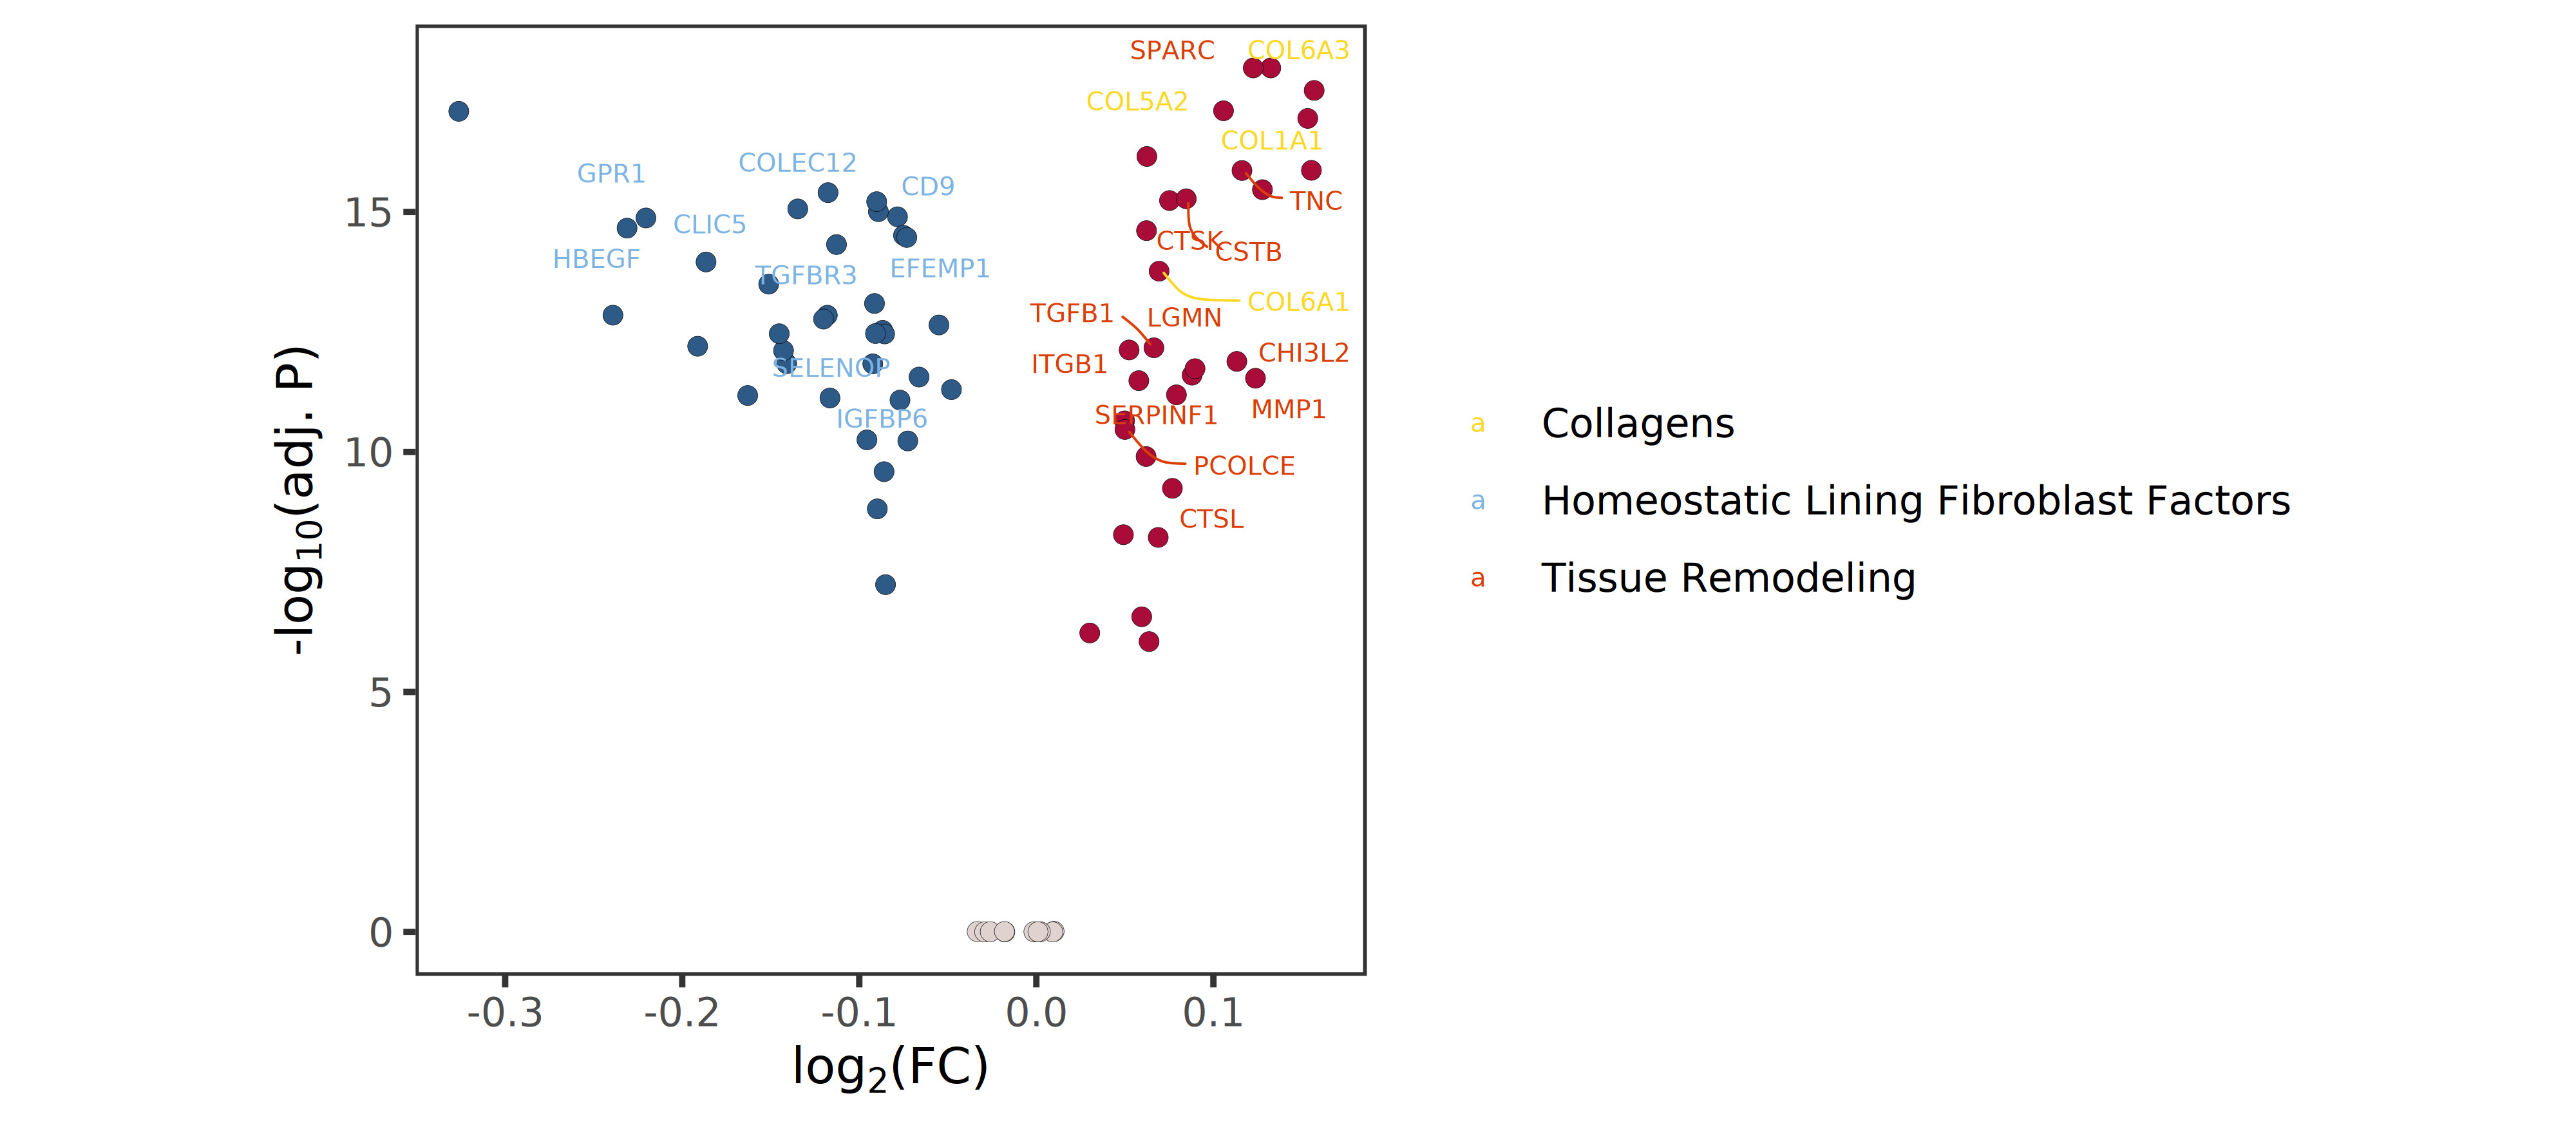

In [133]:
options(repr.plot.width = 8, repr.plot.height = 3.5, repr.plot.res = 500)
ggplot(nde_res_organized, aes(avg_coef, avg_logp, fill=direction, label=label)) +
    geom_point(shape=21, stroke=0.05, size=2) +
    theme_bw() +
    theme(aspect.ratio=1,
          panel.grid=element_blank(),
          legend.position="right") +
    geom_text_repel(aes(label = label, color = gene_label),
                    nudge_x=0.005,
                    nudge_y=0.005,
                    size=2,
                    max.overlaps=20,
                    segment.curvature=-0.1,
                    segment.size=0.2) +
    scale_color_manual(
    values = c(
      "Homeostatic Lining Fibroblast Factors" = "#7DB3E2FF",
      "Tissue Remodeling"       = "#DB3D06FF",
      "Collagens"                = "#FCD723FF"
    ),
    na.translate = F,
    guide = guide_legend(
      ncol = 1,
      title = NULL
    )
  ) +
    scale_fill_manual(values=paletteer_c("ggthemes::Red-Blue Diverging", n=100)[c(100, 50, 1)], guide="none") +
    labs(x=TeX(r"(log$_{2}$(FC))"),
         y=TeX(r"(-log$_{10}$(adj. P))"))
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure1/1J/plot.png",
       height=3.5,
       width=8,
       dpi=500)